# Keratoconus Algorithmic Notebook
This notebook present the algorithmic calculations for the keratoconus project.


-----

## Init

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import plotly.express as pex
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from pandas import MultiIndex, Int16Dtype

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold, LeaveOneOut
from sklearn.metrics import classification_report, accuracy_score, auc, f1_score, average_precision_score, recall_score, precision_score, confusion_matrix, precision_recall_curve, roc_auc_score
from sklearn.metrics import RocCurveDisplay,roc_auc_score,precision_recall_curve, cohen_kappa_score

from collections import Counter, defaultdict
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

from imblearn.ensemble import EasyEnsembleClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE, ADASYN, KMeansSMOTE,SVMSMOTE
from imblearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from skopt import BayesSearchCV

from sktime.transformations.panel.rocket import Rocket
#import shap
#from BorutaShap import BorutaShap

from tqdm import tqdm
import pickle

In [64]:
#Helper functions

def prf_plot(y_pred_prob, y_test):
    thresholds = np.linspace(0,1,1001)
    recall, precision, f1 = [],[],[]
    for t in thresholds:
        tmp_y = (y_pred_prob>t).astype(int)
        recall.append(recall_score(y_test, tmp_y))
        precision.append(precision_score(y_test, tmp_y))
        f1.append(f1_score(y_test, tmp_y))


    fig, ax = plt.subplots(figsize=(15,8))
    ax.plot(thresholds, precision, label = 'Precision')
    ax.plot(thresholds, recall, label = 'Recall')
    ax.plot(thresholds, f1, label = 'F1')

    # #add axis labels to plot
    ax.set_title('Precision-Recall-F1 vs Classification Threshold')
    ax.set_ylabel('Value')
    ax.set_xlabel('Threshold')
    plt.legend()

def canonize_id(id: str):
    id = id.replace('-','')
    
    while (len(id)<8):
        id = '0' + id
    
    if len(id) == 9:
        id = id[:-1]
    return id

def clean_dataset(df):
    assert isinstance(df, pd.DataFrame), "df needs to be a pd.DataFrame"
    df.dropna(inplace=True)
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    return df[indices_to_keep].astype(np.float64)

class ModelStatsTracker:
    def __init__(self, thresholds = np.linspace(0,1,1000)):
        self.metrics = defaultdict(lambda: defaultdict(list))
        self.metric_curves = defaultdict(lambda: defaultdict(list))
        self.thresholds = thresholds
        self.cf_matrices = defaultdict(list)
        self.feature_importances_gain = []
        self.feature_importances_weight = []

    def log(self, model, X_test, y_test):
        for label in [0,1]:
            y_pred, y_pred_prob = model.predict(X_test),model.predict_proba(X_test)[:,label]
            self.metrics[label]['f1'].append(f1_score(y_test, y_pred))
            self.metrics[label]['aps'].append(average_precision_score(y_test, y_pred))
            self.metrics[label]['percision'].append(precision_score(y_test, y_pred))
            self.metrics[label]['recall'].append(recall_score(y_test, y_pred))
            try:
                self.metrics[label]['roc_auc'].append(roc_auc_score(y_test,y_pred_prob))
            except:
                pass

            recall, precision, f1 = [],[],[]
            for t in self.thresholds:
                tmp_y = (y_pred_prob>t).astype(int)
                recall.append(recall_score(y_test, tmp_y, zero_division=0))
                precision.append(precision_score(y_test, tmp_y, zero_division=0))
                f1.append(f1_score(y_test, tmp_y, zero_division=0))

            for t in np.linspace(0,1,21):
                self.cf_matrices[t].append(confusion_matrix(y_test,(y_pred_prob>t).astype(float)))
                    
            self.metric_curves[label]['F1'].append(f1)
            self.metric_curves[label]['Recall'].append(recall)
            self.metric_curves[label]['Precision'].append(precision)

        features = model.get_booster().get_score(importance_type='weight')
        self.feature_importances_weight.append(pd.DataFrame([features.values()], columns=features.keys()))

        features = model.get_booster().get_score(importance_type='gain')
        self.feature_importances_gain.append(pd.DataFrame([features.values()], columns=features.keys()))
            

        

    def plot_metrics(self, label=1, title = 'CV Precision-Recall-F1 vs Classification Threshold'):
        fig, ax = plt.subplots(figsize=(15,8))
        for k in self.metric_curves[label].keys():
            ax.plot(self.thresholds, np.array(self.metric_curves[label][k]).mean(axis=0), label = k)

        
        # #add axis labels to plot
        ax.set_title(title)
        ax.set_ylabel('Value')
        ax.set_xlabel('Threshold')
        plt.legend()

        plt.figure(figsize=(15,8))
        plt.plot(np.mean(self.metric_curves[label]['Recall'],axis=0),np.mean(self.metric_curves[label]['Precision'],axis=0))
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.ylim([0,1])
        plt.title('Precision-Recall')

    def plot_all_cf_matrices(self):
        ths = np.linspace(0,1,21)[:][::2]
        rows, cols, idx = len(ths)//5, 5, 0

        _, axs = plt.subplots(rows, cols, figsize=(25,10))
        for i in range(rows):
            for j in range(cols):
                if idx==len(ths):
                    break

                
                cf_matrix = np.mean(self.cf_matrices[ths[idx]],axis=0)
                group_names = ['True Neg','False Pos','False Neg','True Pos']
                group_counts = ['{0:0.0f}'.format(value) for value in
                                cf_matrix.flatten()]
                group_percentages = ['{0:.2%}'.format(value) for value in
                                    cf_matrix.flatten()/np.sum(cf_matrix)]
                labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
                        zip(group_names,group_counts,group_percentages)]
                labels = np.asarray(labels).reshape(2,2)
                sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues', ax=axs[i,j])
                axs[i,j].set_title(f'CF Matrix $Threshold={np.round(ths[idx],2)}$')
                idx+=1

    def plot_cf_matrix(self,th):
        """
            th = a single value out of np.linspace(0,1,21)
        """
        cf_matrix = np.mean(self.cf_matrices[th],axis=0)
        group_names = ['True Neg','False Pos','False Neg','True Pos']
        group_counts = ['{0:0.0f}'.format(value) for value in
                        cf_matrix.flatten()]
        group_percentages = ['{0:.2%}'.format(value) for value in
                            cf_matrix.flatten()/np.sum(cf_matrix)]
        labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in
                zip(group_names,group_counts,group_percentages)]
        labels = np.asarray(labels).reshape(2,2)
        sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')
        plt.title(f'CF Matrix $Threshold={np.round(th,2)}$')

    def plot_feature_importance(self):
        plt.figure(figsize = (20,10))
        fi = pd.concat(self.feature_importances_weight, ignore_index=True).fillna(0)
        fi.fillna(0).mean().sort_values(ascending=True).plot(kind='barh') ## plot top 40 features
        plt.title('Feature Importance by Weight')

        plt.figure(figsize = (20,10))
        fi = pd.concat(self.feature_importances_gain, ignore_index=True).fillna(0)
        fi.fillna(0).mean().sort_values(ascending=True).plot(kind='barh') ## plot top 40 features
        plt.title('Feature Importance by Gain')

    def print_mean_values(self,label=1):
        for k in self.metrics[label].keys():
            print(f'Mean {k} = {np.round(np.mean(self.metrics[label][k]),2)}')

## Data Loading

In [24]:
df = pd.read_csv('data/221204_v2/KC_filtered_by_date_labeled.csv', dtype={'id': str})

## EDA

### Scan Status

In [6]:
#Scan Status
print(f'# Total scans {len(df)}\n# Filtered STATUS==OK: {len(df[df["Status"]=="OK"])}')
print(f'# Patients {len(df.id.unique())} \n# Patients STATUS==OK: {len(df[df["Status"]=="OK"].id.unique())}')
pex.histogram(df['Status'], title='Scans Status ').update_layout(
    xaxis_title="Status", yaxis_title="Number of Scans")



# Total scans 2828
# Filtered STATUS==OK: 1620
# Patients 645 
# Patients STATUS==OK: 560


Text(0.5, 1.0, 'Label Distribution for Status==OK')

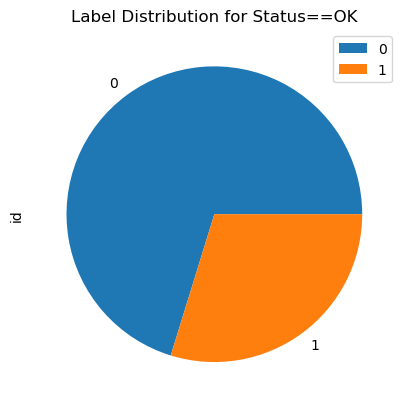

In [15]:
df[df['Status']=='OK'].groupby(['id','Exam Eye:']).agg({'y':'first'}).reset_index().groupby('y').count().plot.pie(y='id')
plt.title('Label Distribution for Status==OK')

### Patients Scans Distribution

In [ ]:
pex.histogram(df[df.Status=='OK'].id.value_counts(), title='Scans Distribution by Patients (Status=OK)').update_layout(
    xaxis_title="Number of Scans", yaxis_title="Number of Patients")

In [ ]:
# pex.histogram(data_frame=df[df['Status']=='OK'].groupby(['id','Exam Eye:']).agg({'y':'first','Exam Type:':'count'}).reset_index().rename(columns={'Exam Eye:':'nscans'}),x='nscans',color='y', title='Scans Distribution by Patients (Status=OK only)').update_layout(
#     xaxis_title="Number of Scans", yaxis_title="Number of Patients")

In [ ]:
#TODO: distibution by id-eye

In [ ]:
pex.histogram(data_frame = df[df['Status']=='OK'], x='id',color='y', title='Scans Distribution by Patients (Status=OK only)').update_layout(
    xaxis_title="Patient ID", yaxis_title="Number of Scans")

### Pachy Values

In [16]:
for c in ['Pachy Apex:','Pachy Min:', 'Pachy Pupil:']:
    fig = pex.histogram(data_frame=df[df.Status=='OK'],x=c, color='y', title=f'{c[:-1]} Raw')
    fig.show()

We filter out scan with $Pachy_{Min} <370$

In [17]:
for c in ['Pachy Apex:','Pachy Min:', 'Pachy Pupil:']:
    fig = pex.histogram(data_frame=df[(df.Status=='OK') & (df['Pachy Min:']>370)],x=c, color='y', title=f'{c[:-1]} wt Pachy Min > 370')
    fig.show()

### Exploring All Numeric Features

In [3]:
eda_numeric_features =['age','Rf F (mm):', 'Rs F (mm):', 'Rh F (mm):', 'Rv F (mm):',
       'K1 F (D):', 'K2 F (D):', 'Rm F (mm):', 'Km F (D):',
       'Astig F (D):', 'R Per F (mm)', 'R Min (mm)', 'Num. Ecc. F:',
       'Asph. Q F:', 'Rf B (mm):', 'Rs B (mm):', 'Rh B (mm):', 'Rv B (mm):',
       'K1 B (D):', 'K2 B (D):', 'Rm B (mm):', 'Km B (mm):',
       'Astig B (D):', 'R Per B (mm):', 'R Min B (mm):', 'Num. Ecc. B:',
       'Asph. Q B:', 'Pachy Apex:', 'Pachy Pupil:',
       'Pupil Pos X:', 'Pupil Pos Y:', 'Pachy Min:', 'Pachy Min Pos X:',
       'Pachy Min Pos Y:', 'C.Vol D 3mm:', 'C.Vol D 5mm:', 'C.Vol D 7mm:',
       'C.Vol D 10mm:', 'ISV:', 'IVA:', 'KI:', 'CKI:', 'IHA:', 'IHD:',
       'RSagMin:', 'D0mm Pachy', 'D2mm Pachy', 'D4mm Pachy',
       'D6mm Pachy', 'D8mm Pachy', 'D10mm Pachy', 'D0mm Prog', 'D2mm Prog',
       'D4mm Prog', 'D6mm Prog', 'D8mm Prog', 'D10mm Prog',
       'KMax Sagittal Front (D)']



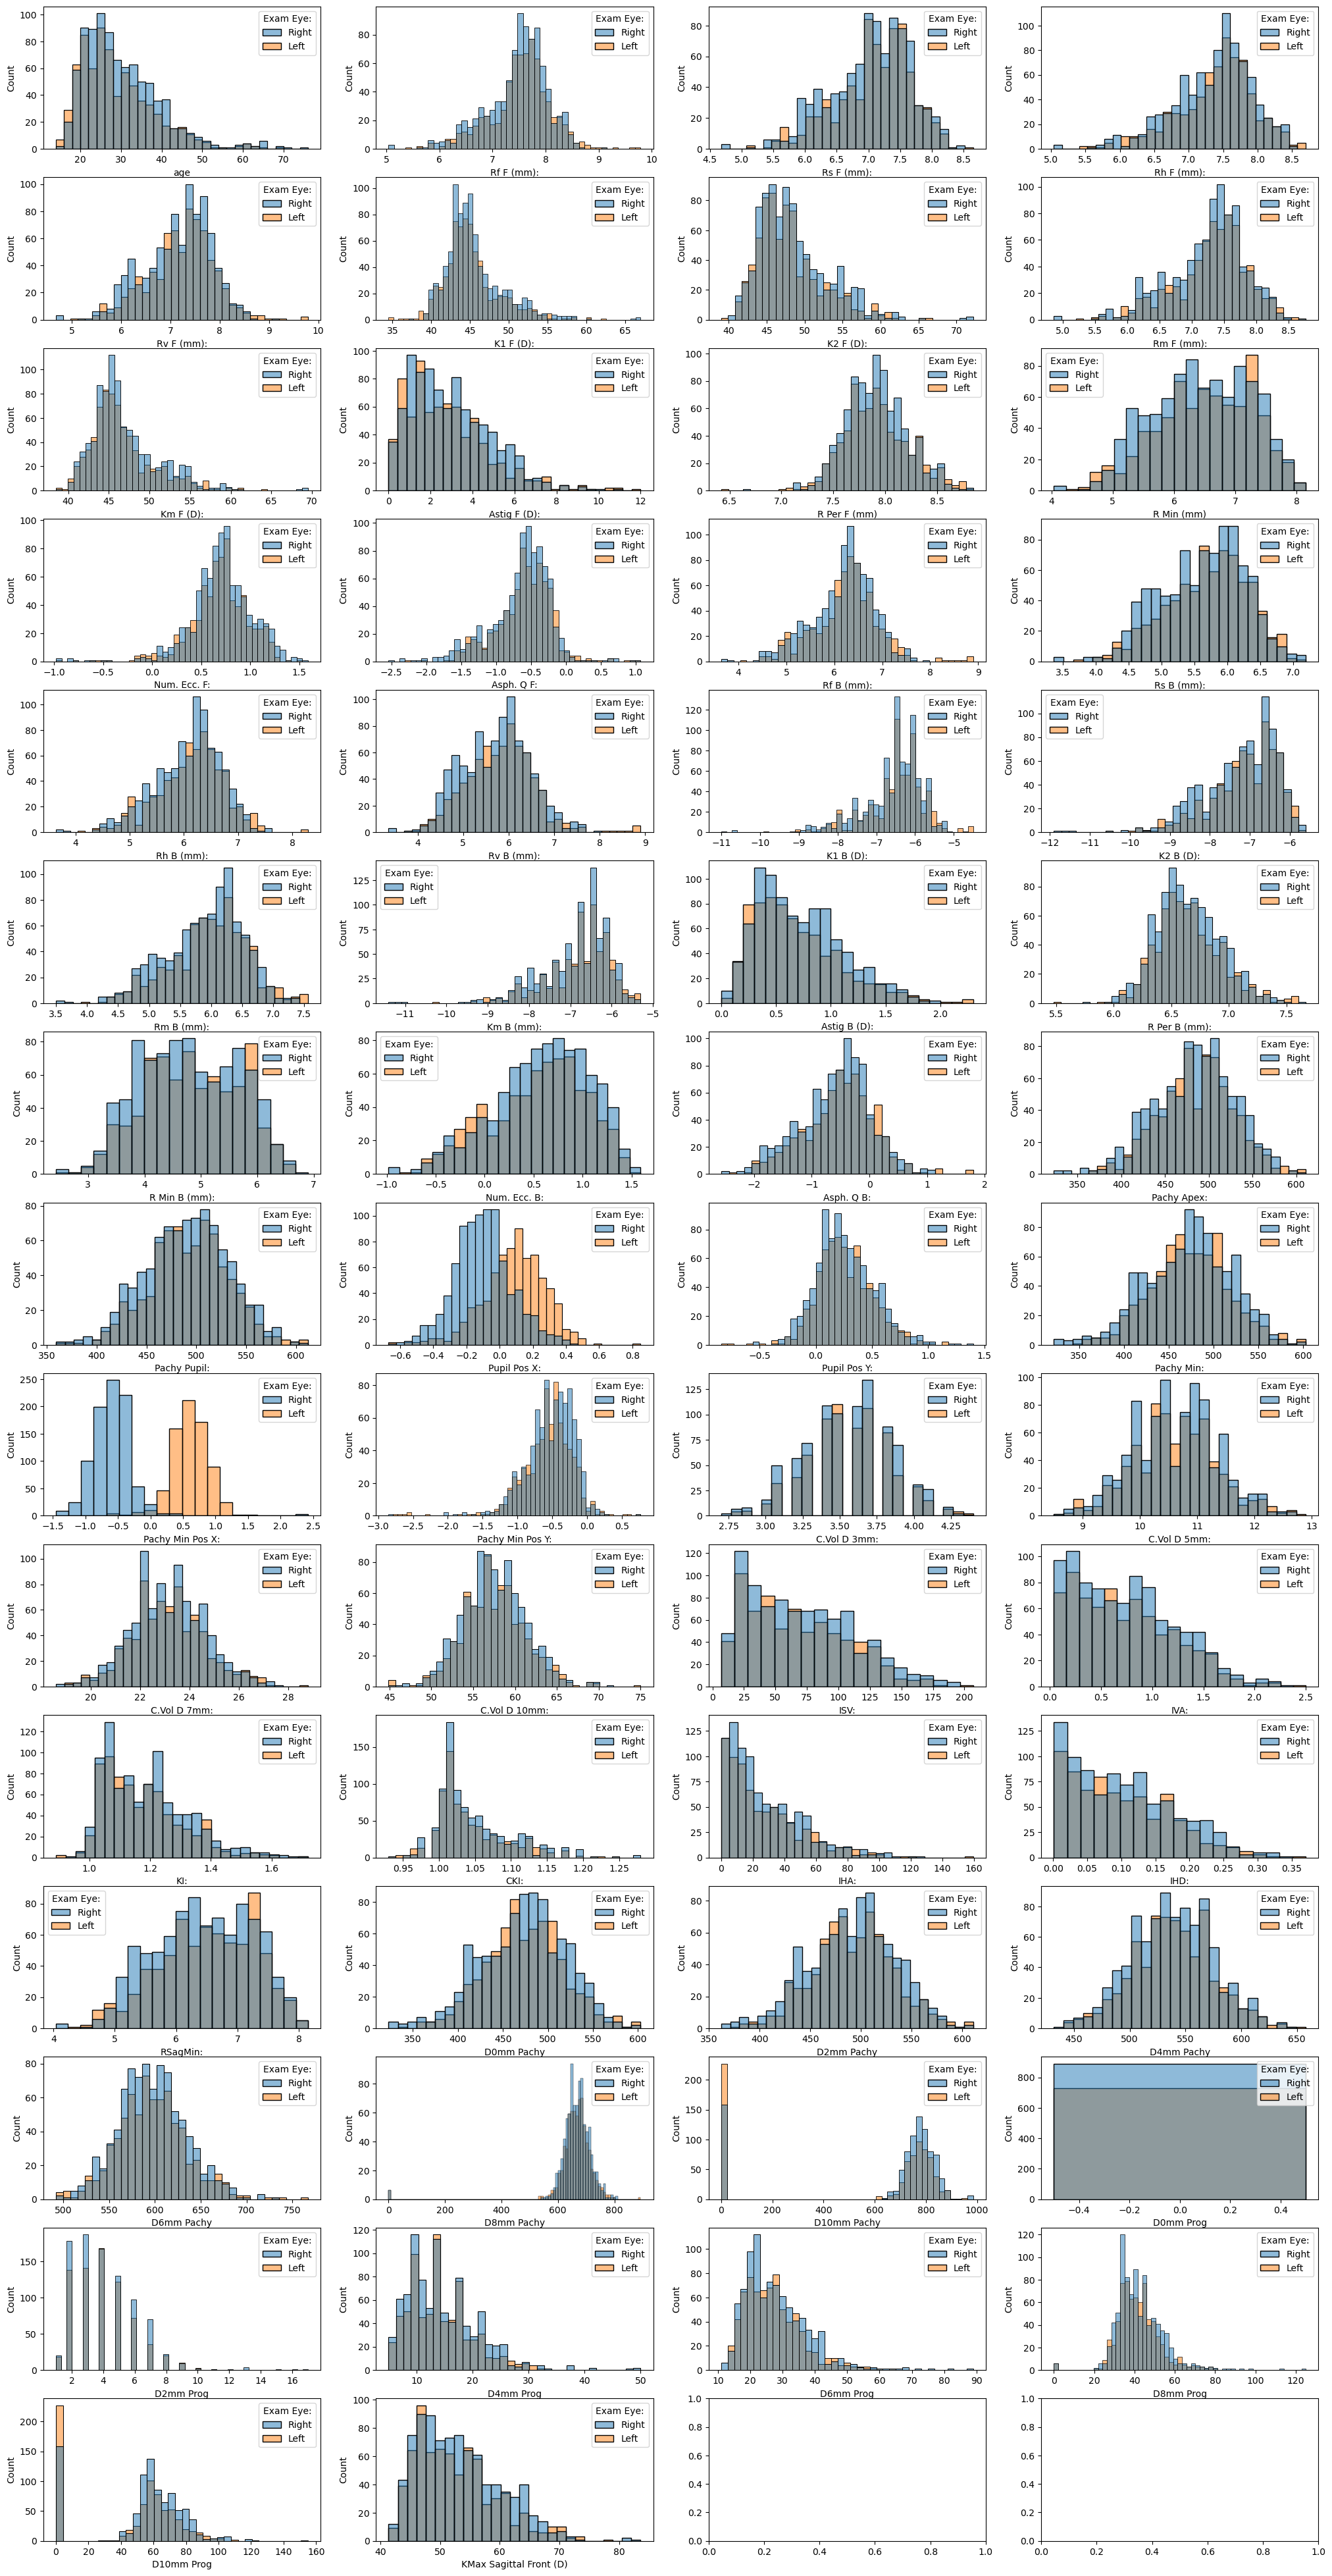

In [19]:
rows, cols, idx = len(eda_numeric_features)//4+1, 4, 0
_, axs = plt.subplots(rows, cols, figsize=(25,50))
for i in range(rows):
    for j in range(cols):
        if idx==len(eda_numeric_features):
            break
        sns.histplot(df[df['Status']=='OK'],x=eda_numeric_features[idx], hue='Exam Eye:', ax=axs[i,j])
        idx+=1


 *  *Pachy Min Pos X* are eye-dependent and of course must be taken as an absolute value
 *  *Pupil Pos X & Y* only exhibits the pupil position in a single test and will not contribute to any analysis
 *  *D10mm Prog* has values of 0 which are invalid and must be filtered
 *  *D0mm Prog* is always 0 thus will not contribute to any analysis

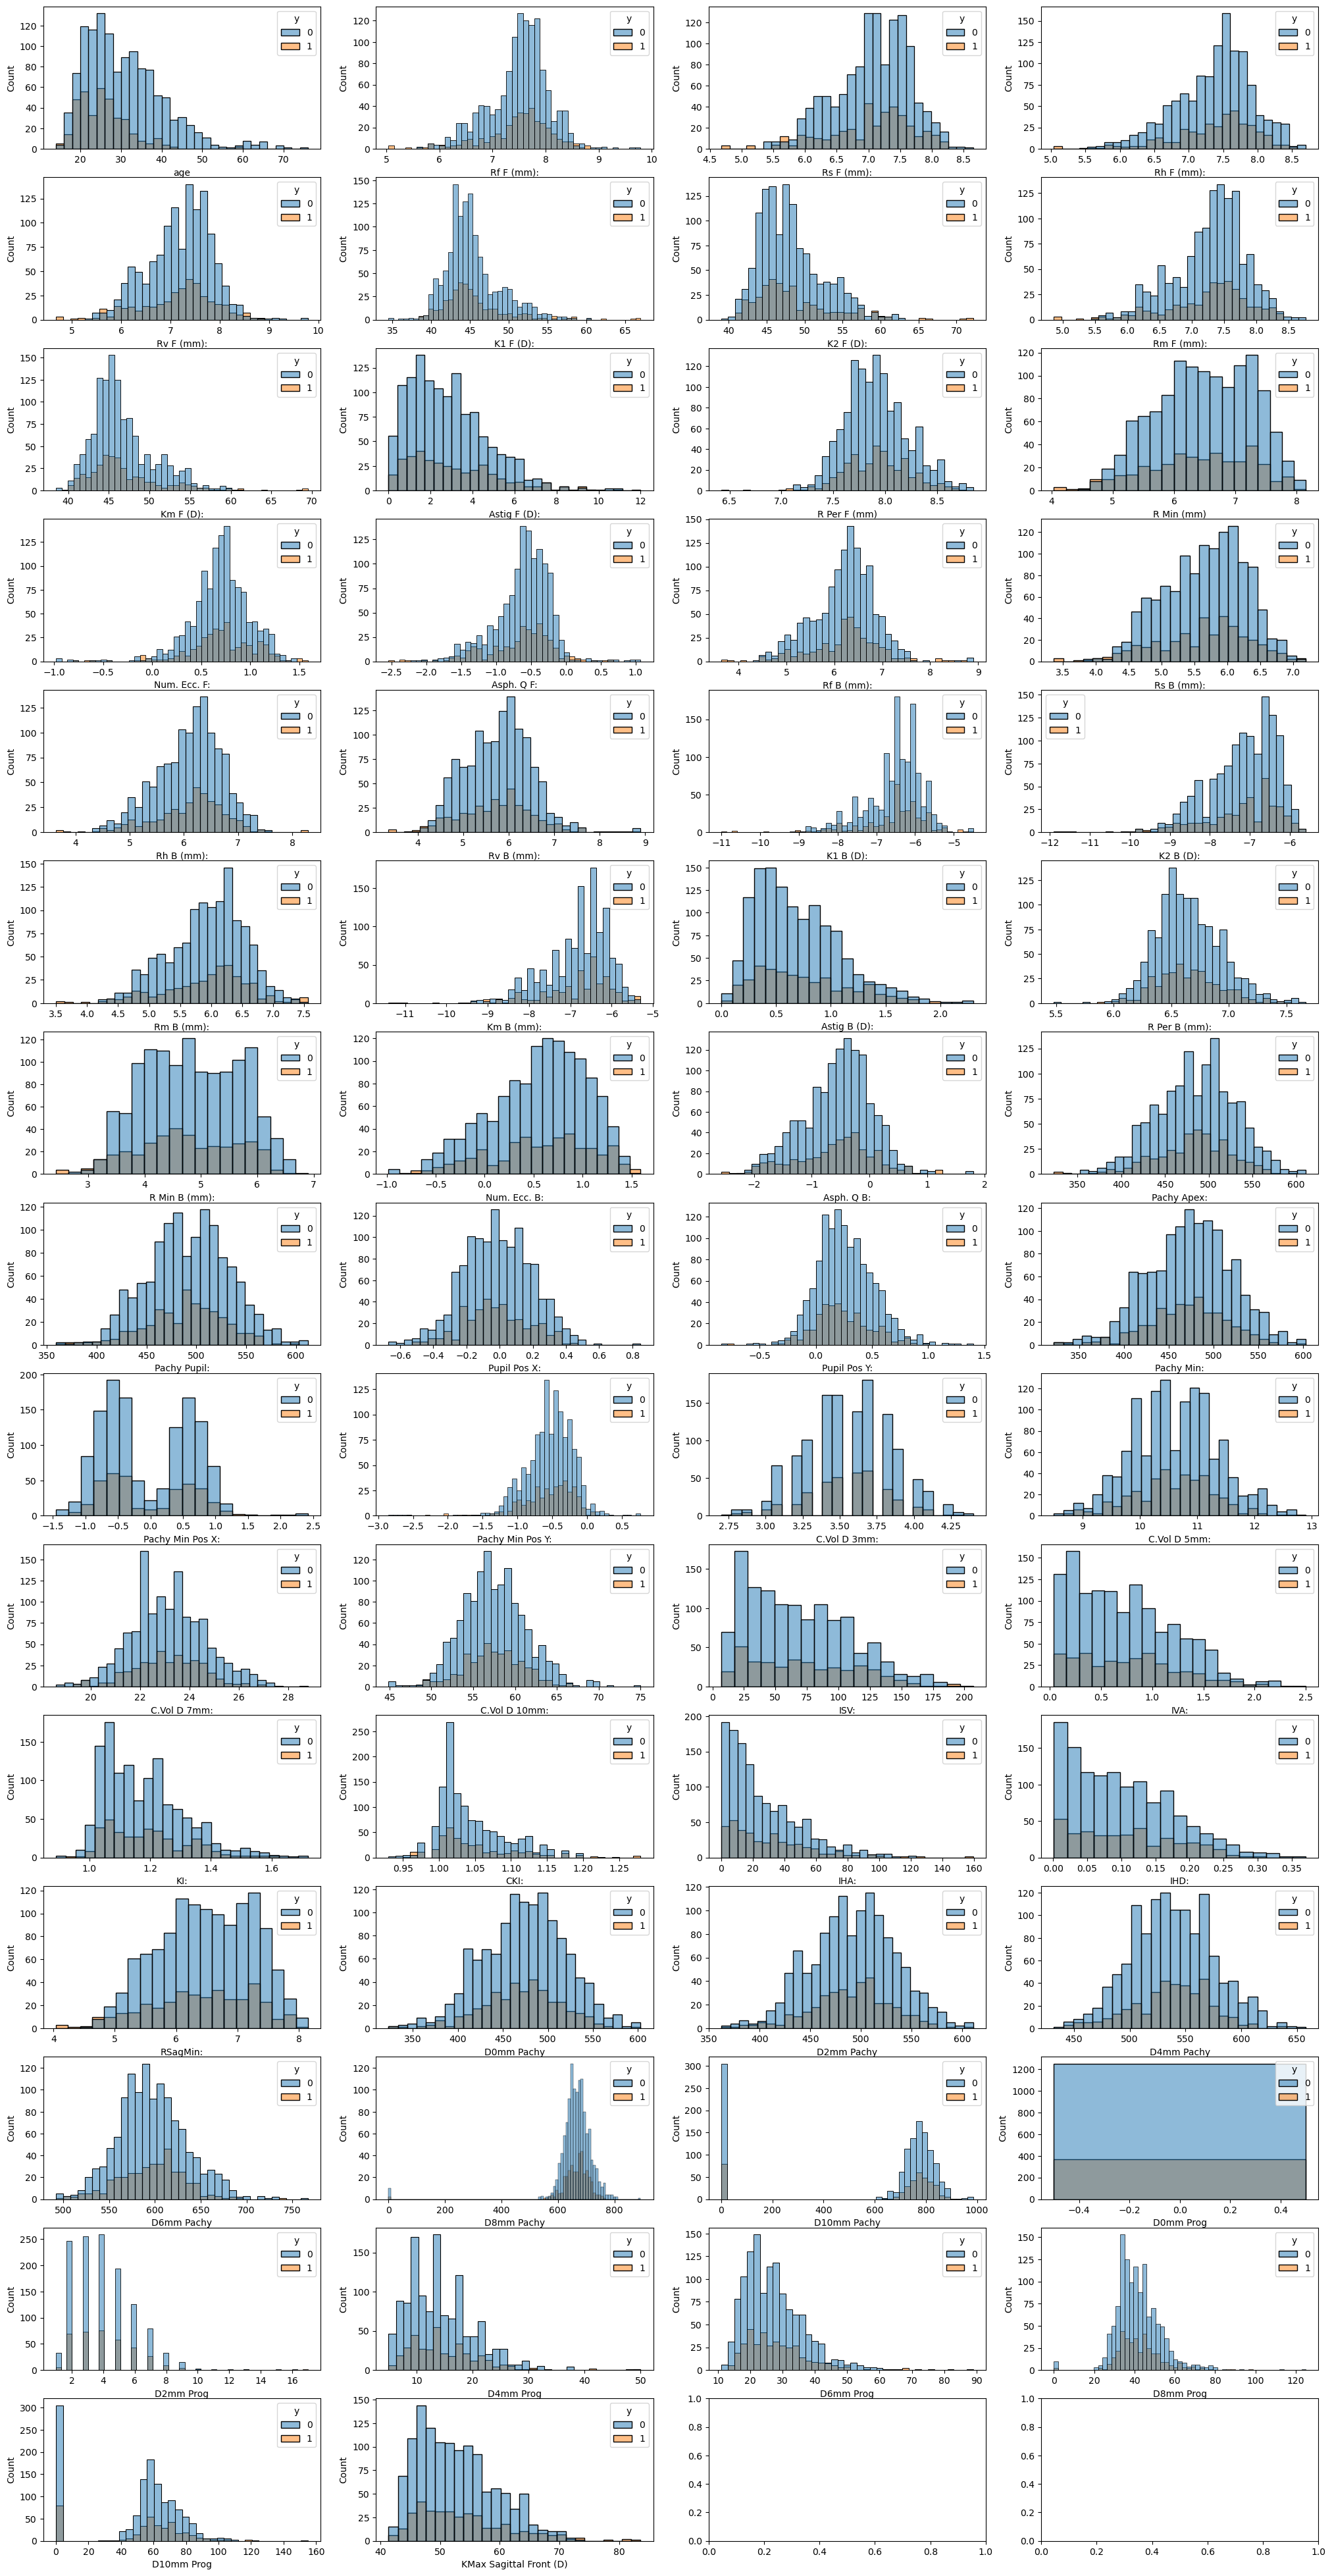

In [20]:
rows, cols, idx = int(np.ceil(len(eda_numeric_features)/4)), 4, 0
_, axs = plt.subplots(rows, cols, figsize=(25,50))
for i in range(rows):
    for j in range(cols):
        if idx==len(eda_numeric_features):
            break
        sns.histplot(df[df['Status']=='OK'],x=eda_numeric_features[idx], hue='y', ax=axs[i,j])
        idx+=1


### Cleaning and Filters

In [16]:
df_filter = df.copy()

In [17]:
#Scan Status
print(f'Pre Status=OK Filter: {len(df_filter)}')
df_filter = df_filter[df_filter['Status']=='OK']
print(f'Post Status=OK Filter: {len(df_filter)}')

Pre Status=OK Filter: 2828
Post Status=OK Filter: 1620


In [18]:
#Pachy Min < 370
print(f'Pre PachyMin<370 Filter: {len(df_filter)}')
print(f'Pre PachyMin<370 Filter #Patients: {len(df_filter.id.unique())}')

df_filter = df_filter[df_filter['Pachy Min:']>370]
print(f'Post PachyMin<370 Filter: {len(df_filter)}')
print(f'Post PachyMin<370 Filter #Patients: {len(df_filter.id.unique())}')


Pre PachyMin<370 Filter: 1620
Pre PachyMin<370 Filter #Patients: 560
Post PachyMin<370 Filter: 1594
Post PachyMin<370 Filter #Patients: 553


In [19]:
#D10mm Pachy & Prog
print(f'Pre D10mm Prog and D10mm Pachy Filter: {len(df_filter)}')
print(f'Pre D10mm Prog Filter #Patients: {len(df_filter.id.unique())}')
for c in ['D10mm Prog','D10mm Pachy']:
    df_filter = df_filter[df_filter[c]>0]
print(f'Post D10mm Prog and D10mm Pachy Filter: {len(df_filter)}')
print(f'Post D10mm Prog Filter #Patients: {len(df_filter.id.unique())}')


Pre D10mm Prog and D10mm Pachy Filter: 1594
Pre D10mm Prog Filter #Patients: 553
Post D10mm Prog and D10mm Pachy Filter: 1218
Post D10mm Prog Filter #Patients: 481


In [62]:
# Abs values
df_filter['Pupil Pos X:']= df_filter['Pupil Pos X:'].abs()
df_filter['Pachy Min Pos X:']= df_filter['Pachy Min Pos X:'].abs()

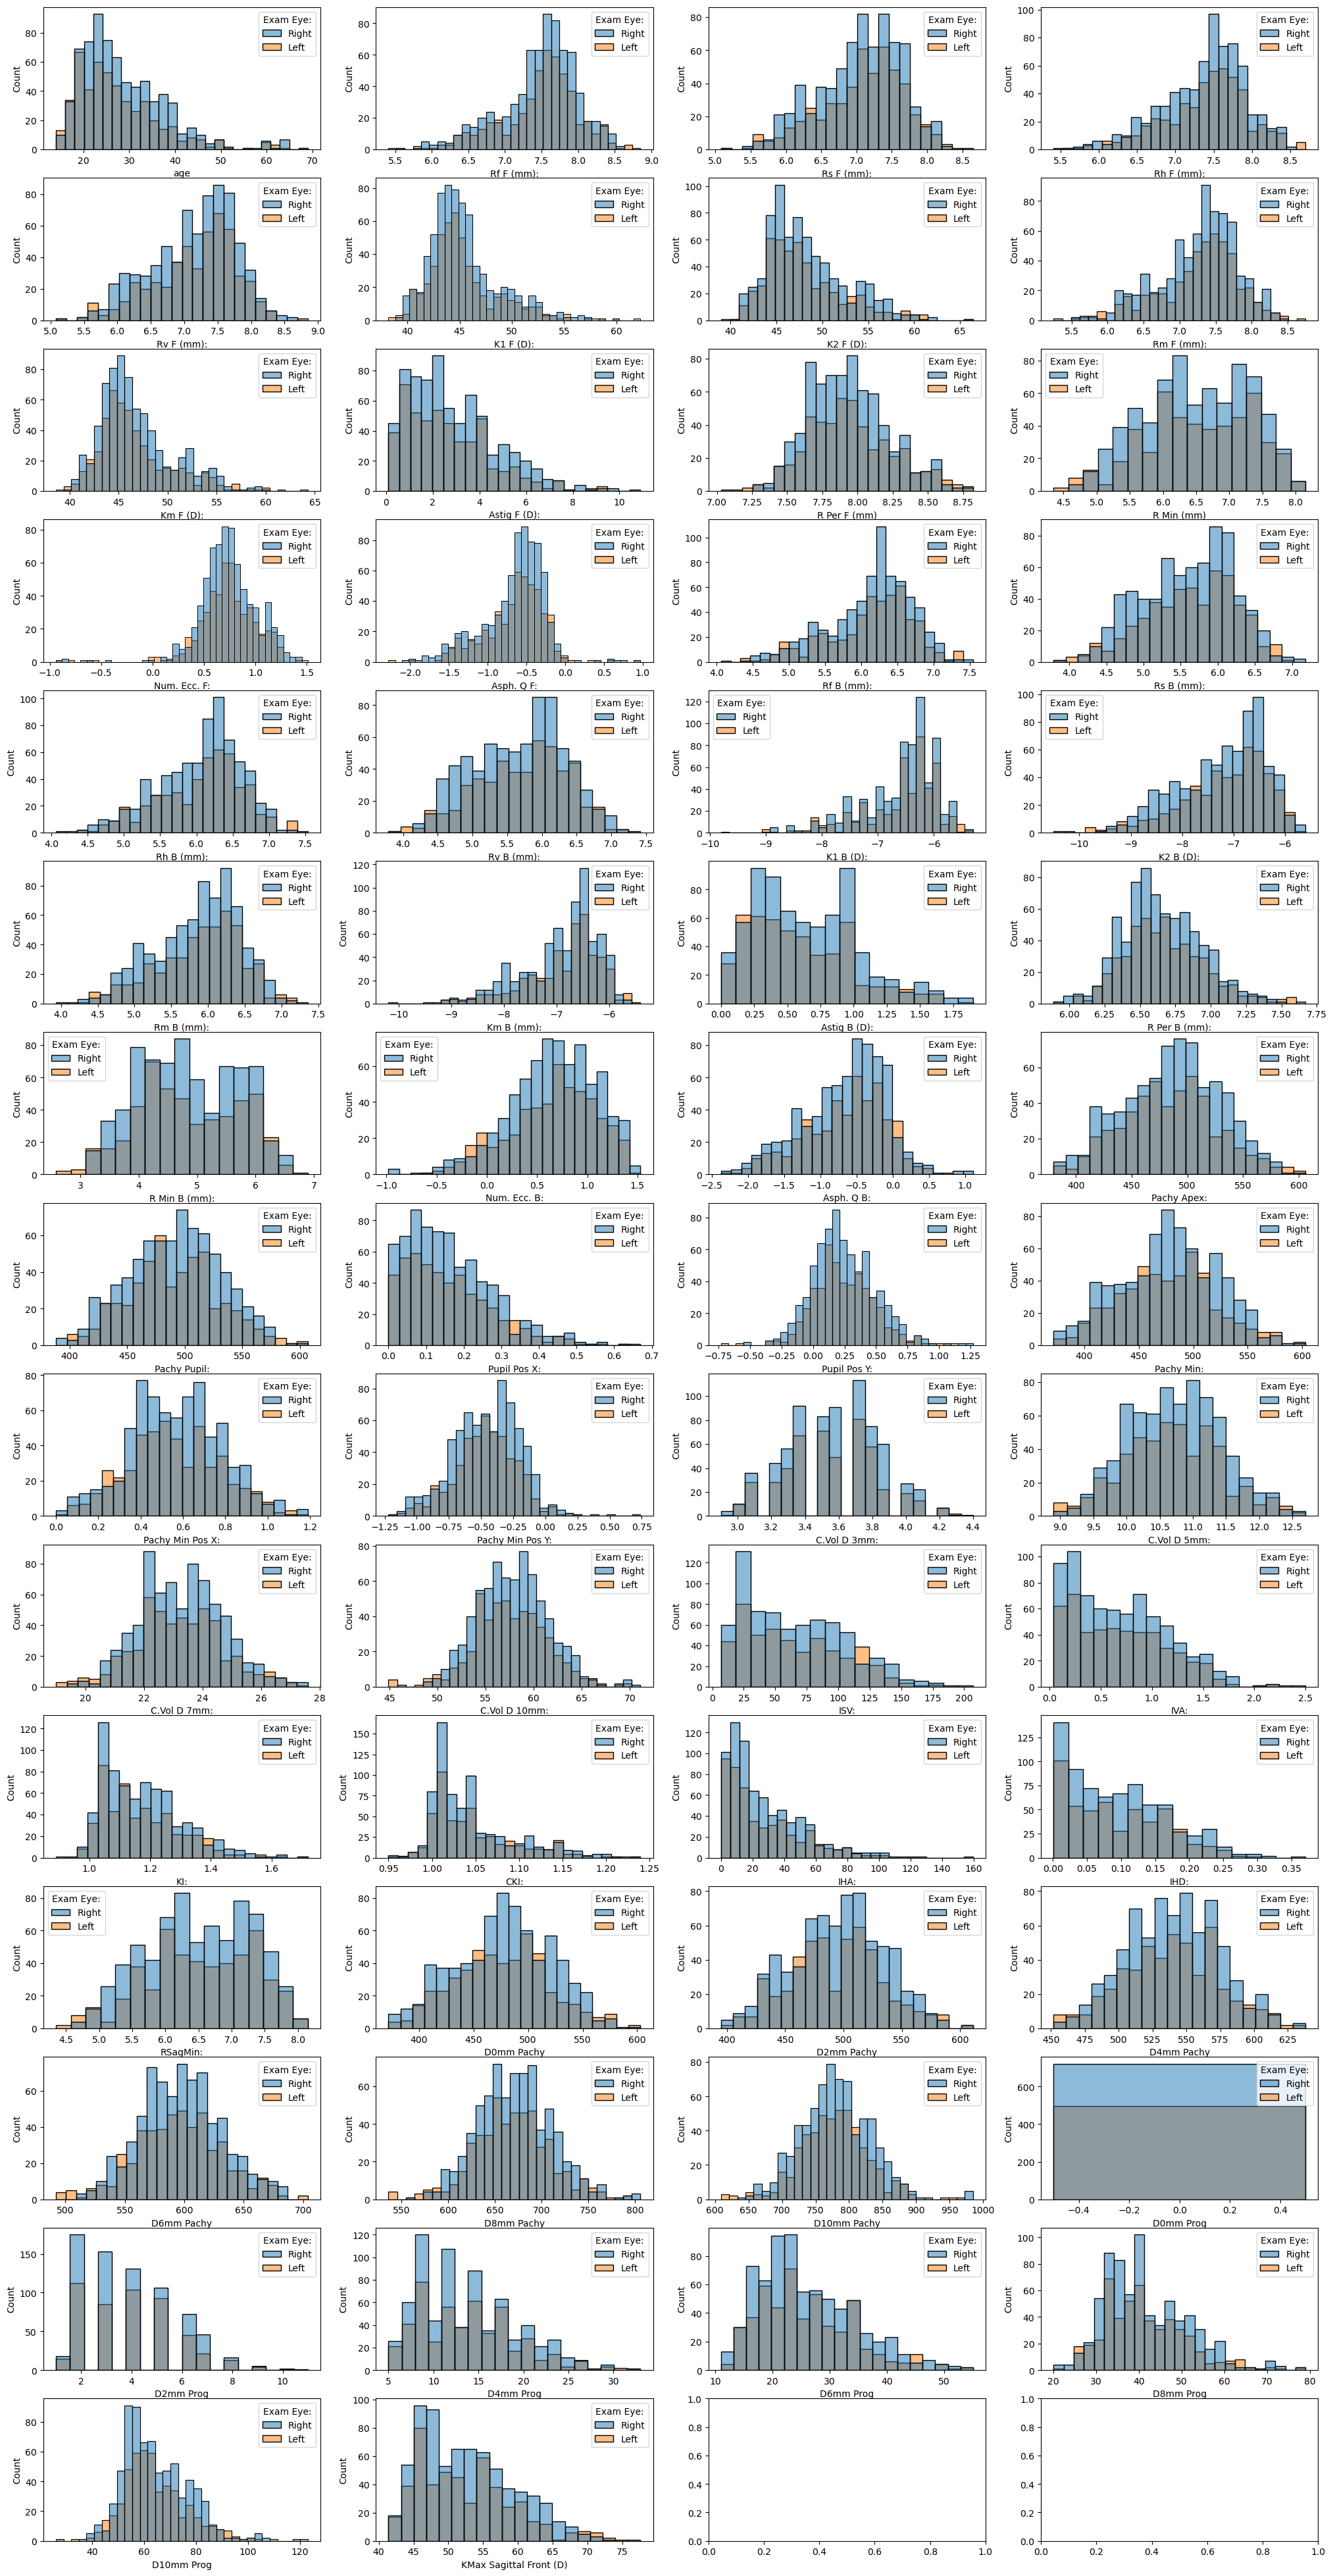

In [63]:
rows, cols, idx = len(eda_numeric_features)//4+1, 4, 0
_, axs = plt.subplots(rows, cols, figsize=(25,50))
for i in range(rows):
    for j in range(cols):
        if idx==len(eda_numeric_features):
            break
        sns.histplot(df_filter,x=eda_numeric_features[idx],hue='Exam Eye:', ax=axs[i,j])
        idx+=1

In [67]:
# rows, cols, idx = len(eda_numeric_features)//4+1, 4, 0
# _, axs = plt.subplots(rows, cols, figsize=(25,50))
# for i in range(rows):
#     for j in range(cols):
#         if idx==len(eda_numeric_features):
#             break
#         sns.histplot(df_filter,x=eda_numeric_features[idx],hue='y', ax=axs[i,j])
#         idx+=1

### Data Selection

#### Earliest Exam Only

In [ ]:
# Can We take only a single (earliest) sample from a patient, thus not skewing our dataset
df_single_earliest = df_filter.sort_values('Exam Date:').groupby(['id','Exam Eye:']).first().reset_index()
df_train = df_single_earliest.reindex(np.random.permutation(df_single_earliest.index))   
df_train.y.mean()

#### All Data

In [39]:
df_train = df_filter.reindex(np.random.permutation(df_filter.index))   
#df_train.dropna(subset=training_features,inplace=True)
print(f'CXL Percentage: {100*np.round(df_train.y.mean(),2)}%')

CXL Percentage: 23.0%


==> Our data has only 23% scans which belongs to a CXL patients, meaning its un-balanced.

### Correlations

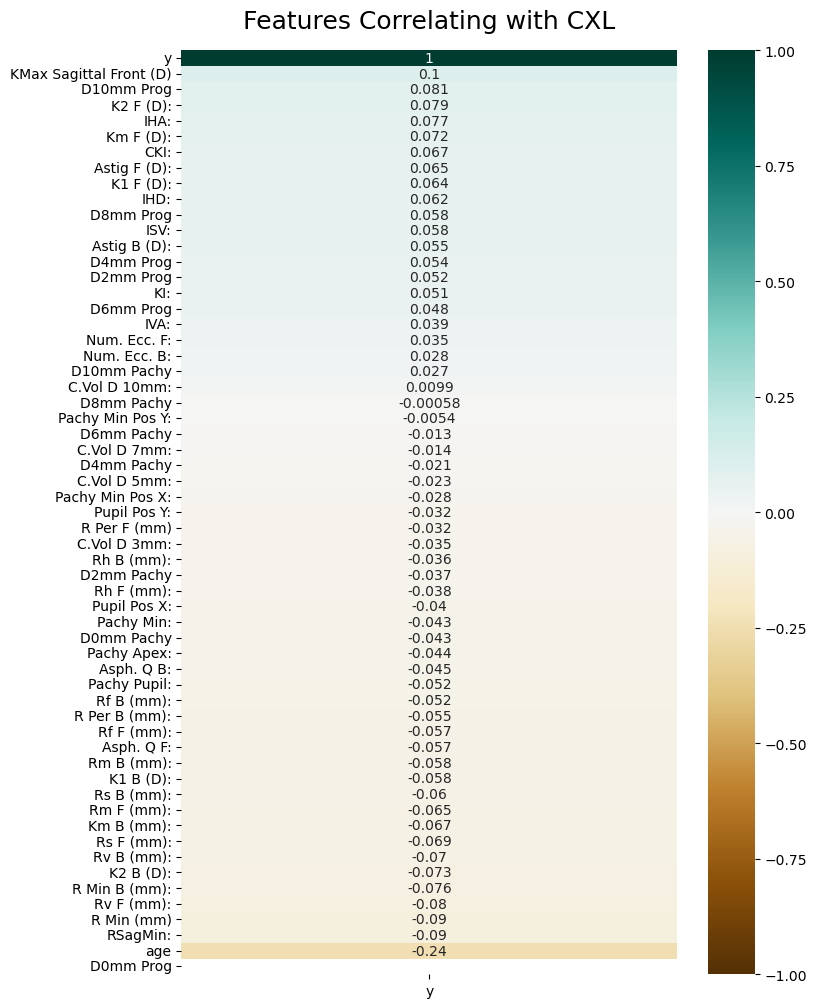

In [43]:
plt.figure(figsize=(8, 12))
heatmap = sns.heatmap(df_filter[eda_numeric_features + ['y']].corr()[['y']].sort_values(by='y', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Features Correlating with CXL', fontdict={'fontsize':18}, pad=16);

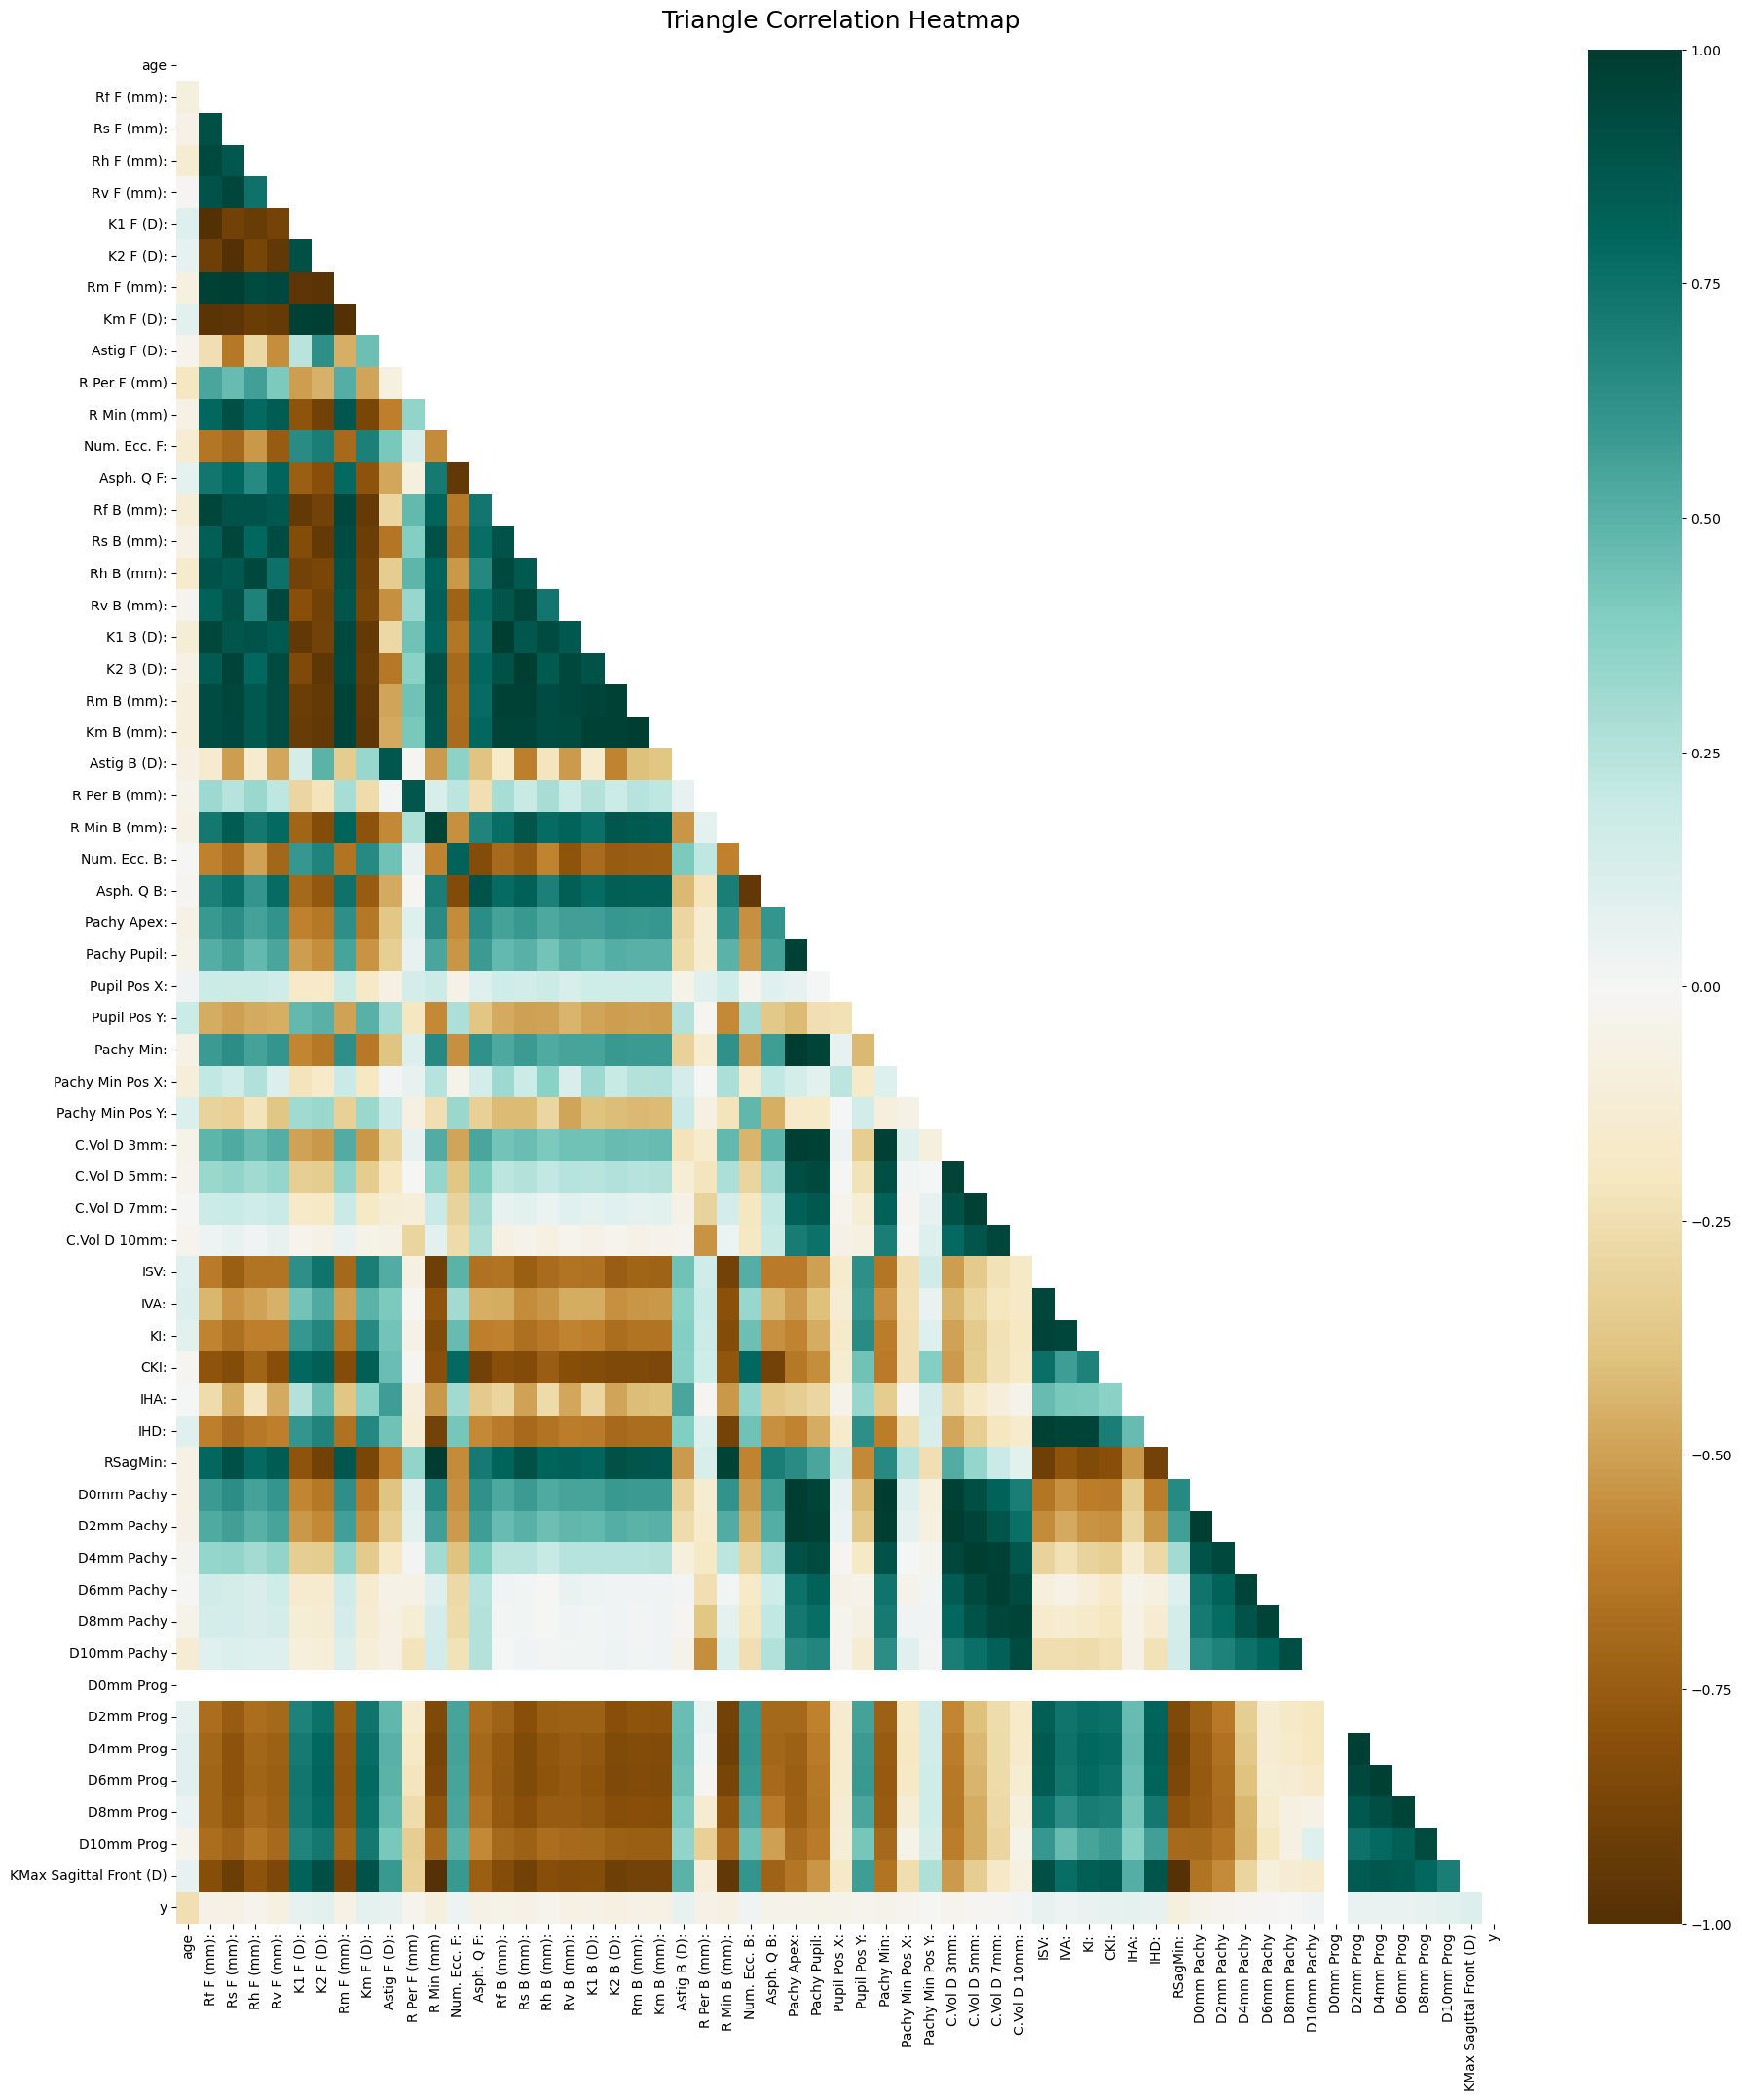

In [44]:
plt.figure(figsize=(22, 25))
# define the mask to set the values in the upper triangle to True
dfcorr = df_filter[eda_numeric_features + ['y']].corr()
mask = np.triu(np.ones_like(dfcorr, dtype=bool))
heatmap = sns.heatmap(dfcorr, mask=mask, vmin=-1, vmax=1, annot=False, cmap='BrBG')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

### Dimensionality Reduction

#### PCA

In [ ]:
principalComponents2d = PCA(n_components=2).fit_transform(df_train[eda_numeric_features])
principalComponents3d = PCA(n_components=3).fit_transform(df_train[eda_numeric_features])

In [ ]:
fig_2d = pex.scatter(
    principalComponents2d, x=0, y=1,
    color=df_train.y.astype(str), labels={'color': 'CXL'},
    
)
fig_3d = pex.scatter_3d(
    principalComponents3d, x=0, y=1, z=2,
    color=df_train.y.astype(str), labels={'color': 'CXL'},
    title='PCA + CXL Label'
)
fig_2d.update_traces(marker_size=3)
fig_3d.update_traces(marker_size=2)

fig_2d.show()
fig_3d.show()

#### tSNE

In [ ]:
n_components = 2
tsne = TSNE(random_state = 42, n_components=n_components,verbose=0, perplexity=40, n_iter=400).fit_transform(df_train[eda_numeric_features])

for i in range(n_components):
    df_train[f't{i}'] = tsne[:,i]

In [ ]:
pex.scatter(data_frame=df_train, x='t0',y='t1', color='y', hover_data=['id'], title='tSNE + CXL Label')

In [ ]:
pex.scatter(data_frame=df_train, x='t0',y='t1', color='Exam Eye:', hover_data=['id'], title = 'tSNE + Exam Eye')

#### UMAP

In [ ]:
from umap import UMAP

umap_2d = UMAP(n_components=2, init='random', random_state=0)
umap_3d = UMAP(n_components=3, init='random', random_state=0)

proj_2d = umap_2d.fit_transform(df_train[eda_numeric_features])
proj_3d = umap_3d.fit_transform(df_train[eda_numeric_features])

In [ ]:
fig_2d = pex.scatter(
    proj_2d, x=0, y=1,
    color=df_train.y.astype(str), labels={'color': 'CXL'}
)
fig_3d = pex.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=df_train.y.astype(str), labels={'color': 'CXL'}
)
fig_2d.update_traces(marker_size=3)

fig_3d.update_traces(marker_size=2)

fig_2d.show()
fig_3d.show()

## Single Test Models

In [4]:
# Final Data Selection
df_filter = df.copy()


#Scan Status

df_filter = df_filter[df_filter['Status']=='OK']
#Pachy Min < 370
df_filter = df_filter[df_filter['Pachy Min:']>370]
#D10mm Pachy & Prog
for c in ['D10mm Prog','D10mm Pachy']:
    df_filter = df_filter[df_filter[c]>0]
# Abs values
df_filter['Pupil Pos X:']= df_filter['Pupil Pos X:'].abs()
df_filter['Pachy Min Pos X:']= df_filter['Pachy Min Pos X:'].abs()

# df_single_earliest = df_filter.sort_values('Exam Date:').groupby(['id','Exam Eye:']).head(1).reset_index()
# df_train = df_single_earliest.reindex(np.random.permutation(df_single_earliest.index))   
df_features = df_filter.reindex(np.random.permutation(df_filter.index))  
print(f'# Scans: {len(df_features)}')
print(f'#Patients: {len(df_features.id.unique())}')

print(f'# Scans: {len(df_features[df_features.y==0])}')
print(f'#Patients: {len(df_features[df_features.y==0].id.unique())}')

print(f'# Scans: {len(df_features[df_features.y==1])}')
print(f'#Patients: {len(df_features[df_features.y==1].id.unique())}')

# Scans: 1218
#Patients: 481
# Scans: 935
#Patients: 374
# Scans: 283
#Patients: 167


In [5]:
numeric_features =['age', 'Rf F (mm):', 'Rs F (mm):', 'Rh F (mm):', 'Rv F (mm):',
       'K1 F (D):', 'K2 F (D):', 'Rm F (mm):', 'Km F (D):',
       'Astig F (D):', 'R Per F (mm)', 'R Min (mm)', 'Num. Ecc. F:',
       'Asph. Q F:', 'Rf B (mm):', 'Rs B (mm):', 'Rh B (mm):', 'Rv B (mm):',
       'K1 B (D):', 'K2 B (D):', 'Rm B (mm):', 'Km B (mm):',
       'Astig B (D):', 'R Per B (mm):', 'R Min B (mm):', 'Num. Ecc. B:',
       'Asph. Q B:', 'Pachy Apex:', 'Pachy Pupil:', 'Pachy Min:', 'Pachy Min Pos X:',
       'Pachy Min Pos Y:', 'C.Vol D 3mm:', 'C.Vol D 5mm:', 'C.Vol D 7mm:',
       'C.Vol D 10mm:', 'ISV:', 'IVA:', 'KI:', 'CKI:', 'IHA:', 'IHD:',
       'RSagMin:', 'D0mm Pachy', 'D2mm Pachy', 'D4mm Pachy',
       'D6mm Pachy', 'D8mm Pachy', 'D10mm Pachy', 'D2mm Prog',
       'D4mm Prog', 'D6mm Prog', 'D8mm Prog', 'D10mm Prog',
       'KMax Sagittal Front (D)']

#numeric_features=list(set(subset_columns))
df_features = df_features.dropna(subset = numeric_features)

df_features['ideye'] = df_features.apply(lambda x: f"{x['id']}-{x['Exam Eye:']}", axis=1)
df_eyes = df_features.groupby('ideye').y.mean().astype(int).reset_index()
df_eyes.describe()

,y
count,677.000000
mean,0.298375
std,0.457883
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


### Feature Selection

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=10)    
subset_columns = []

for fold, (train_idx, test_idx) in enumerate(cv.split(df_eyes['ideye'], df_eyes['y'])):
    X_train = df_features[df_features.ideye.isin(df_eyes['ideye'].iloc[train_idx])][numeric_features]
    y_train = df_features[df_features.ideye.isin(df_eyes['ideye'].iloc[train_idx])]['y'].values


    Feature_Selector = BorutaShap(
                                importance_measure='shap',
                                classification=True)

    Feature_Selector.fit(X=X_train, y=y_train, n_trials=100, sample=False, normalize=True,
                verbose=True)
    subset_columns+= Feature_Selector.tentative + Feature_Selector.accepted
 
subset_columns = list(set(subset_columns))
pickle.dump(subset_columns, open('Feature_selection_single_test.bin','wb'))

In [59]:
print(subset_columns)
print(len(subset_columns))

['ISV:', 'R Min B (mm):', 'KMax Sagittal Front (D)', 'D0mm Pachy', 'Num. Ecc. F:', 'Asph. Q F:', 'RSagMin:', 'Rh F (mm):', 'K2 F (D):', 'C.Vol D 7mm:', 'IHA:', 'R Per B (mm):', 'Num. Ecc. B:', 'Astig B (D):', 'Pachy Min:', 'R Per F (mm)', 'Rh B (mm):', 'D10mm Prog', 'R Min (mm)', 'Pachy Pupil:', 'Rv F (mm):', 'D10mm Pachy', 'age', 'Pachy Apex:']
24


In [6]:
subset_columns = pickle.load(open('Feature_selection_single_test.bin','rb'))

### Save Final Feature Distributions

In [10]:
df_features['CXL'] = df_features['y'].astype(bool)

tmp_subset_columns = []
mapper = {}
for col in subset_columns:
    if col == 'age':
        new_col = 'Mean Age'
    else:
        new_col = col.replace(':','')

    mapper[col] = new_col
    tmp_subset_columns.append(new_col)
df_features.rename(columns=mapper, inplace=True) 
subset_columns = tmp_subset_columns

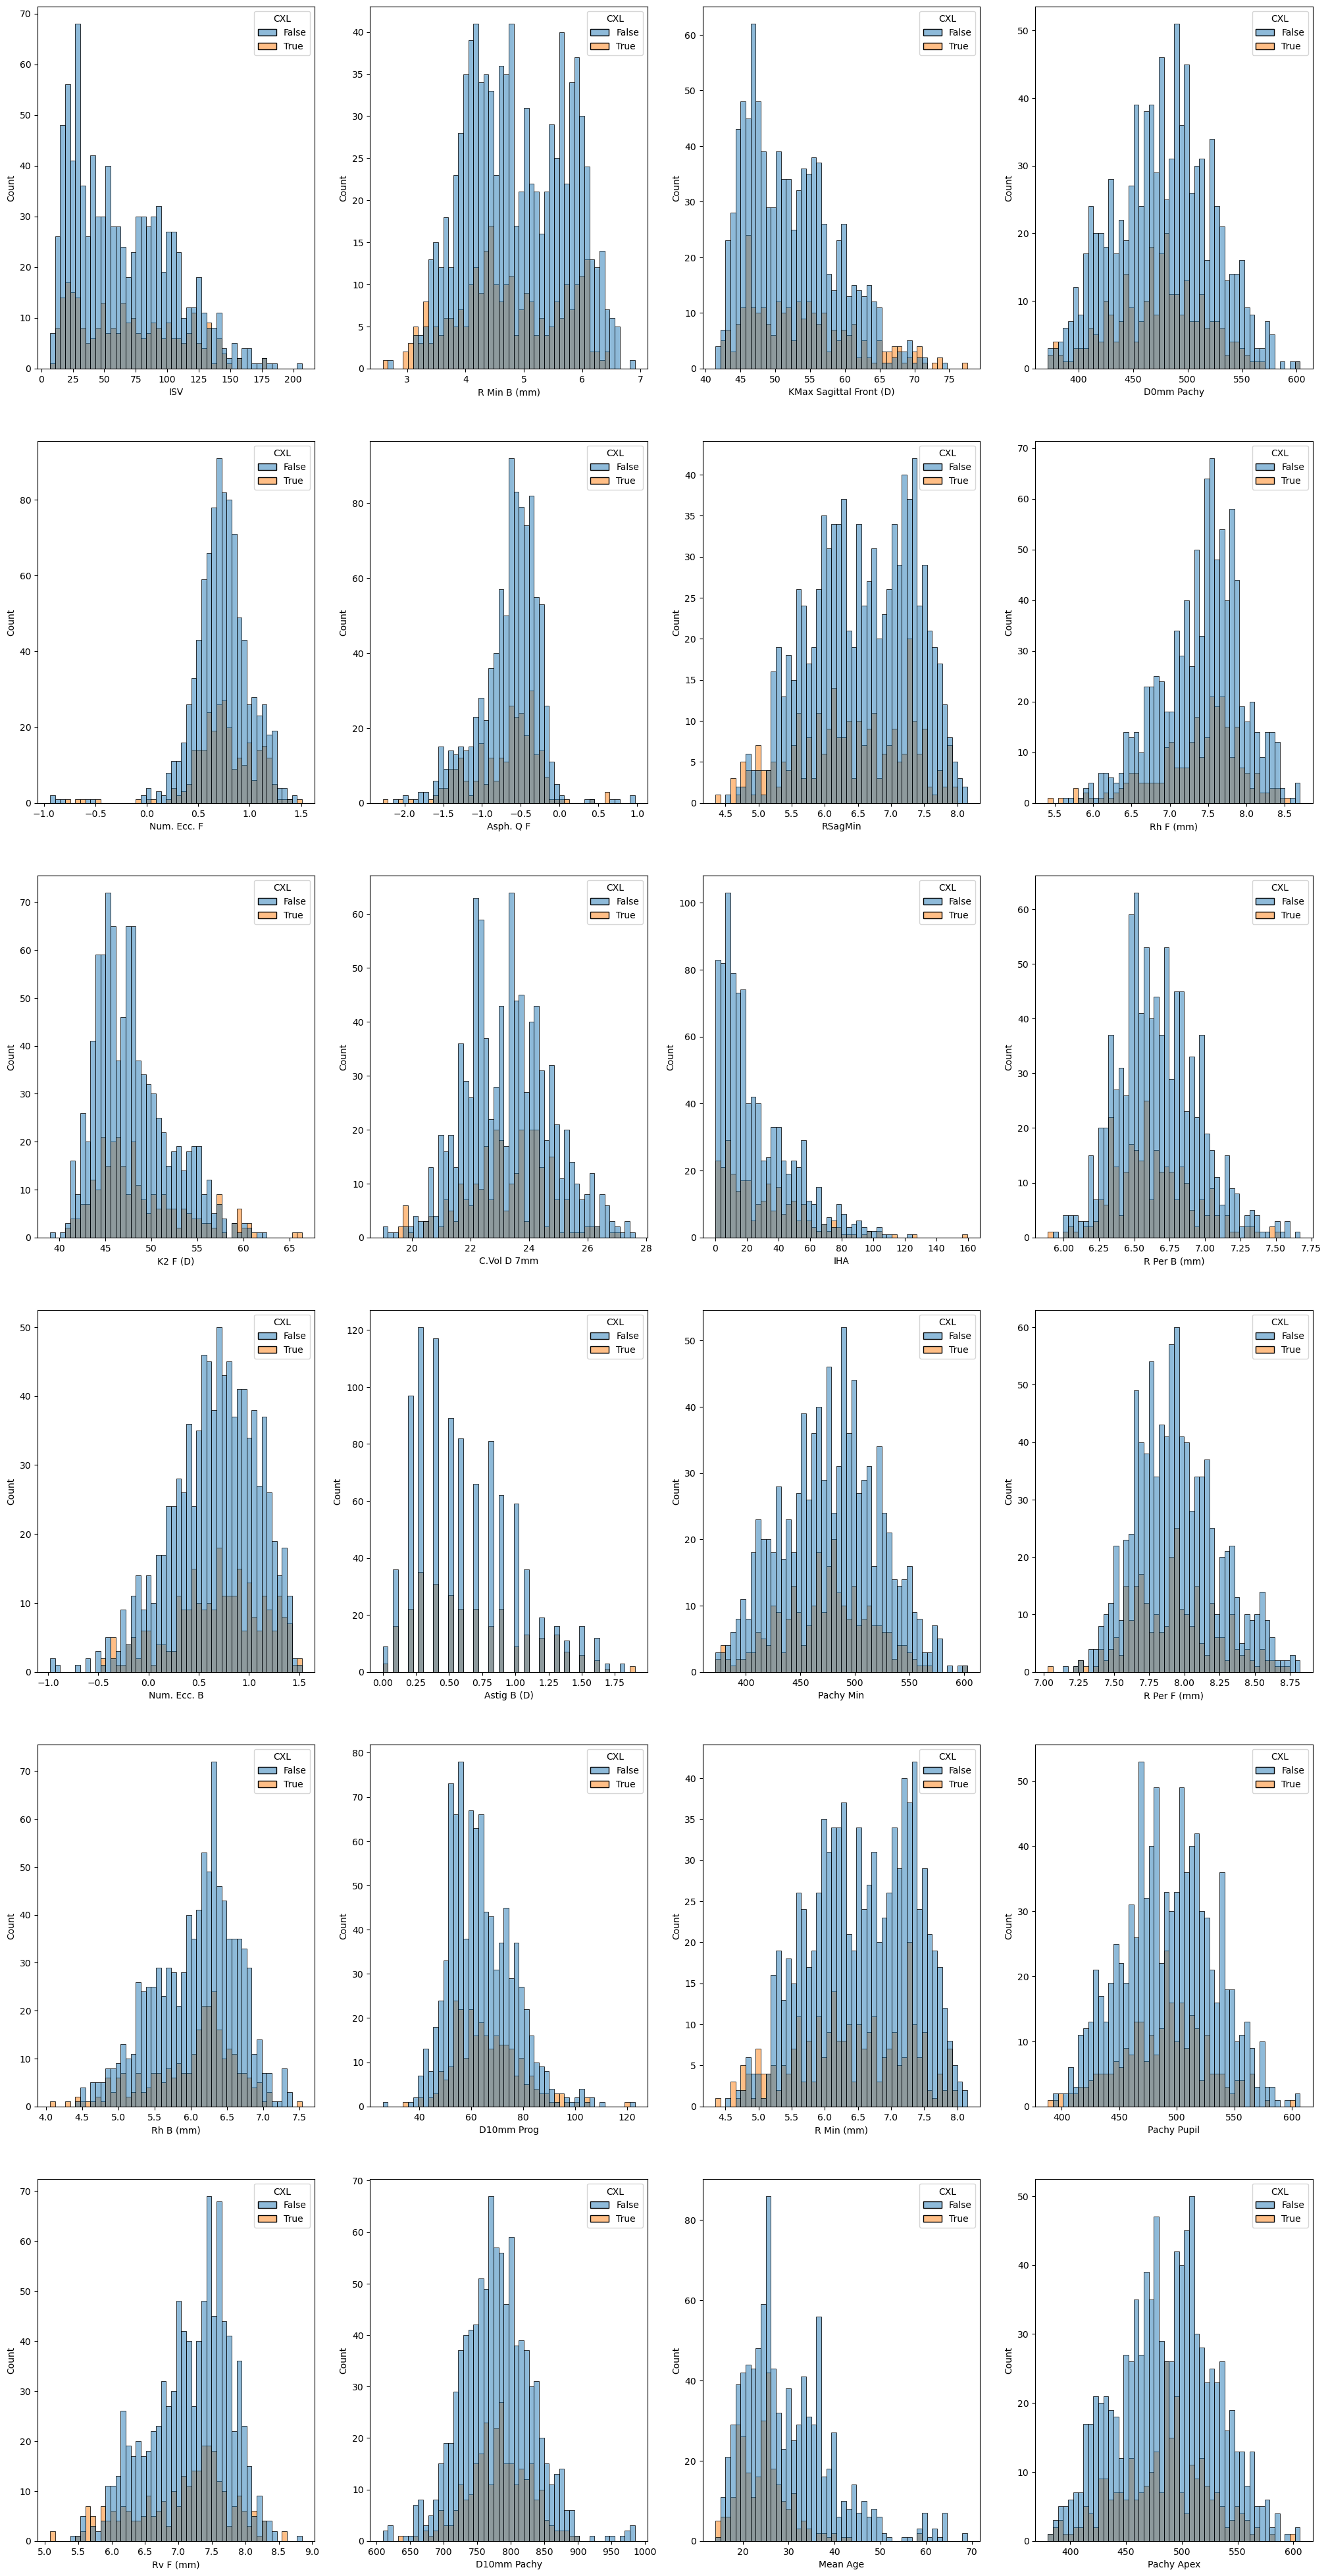

In [12]:
rows, cols, idx = len(subset_columns)//4, 4, 0
_, axs = plt.subplots(rows, cols, figsize=(25,50))
for i in range(rows):
    for j in range(cols):
        if idx==len(subset_columns):
            break
        sns.histplot(df_features,x=subset_columns[idx],bins=50, hue='CXL', ax=axs[i,j])
        idx+=1

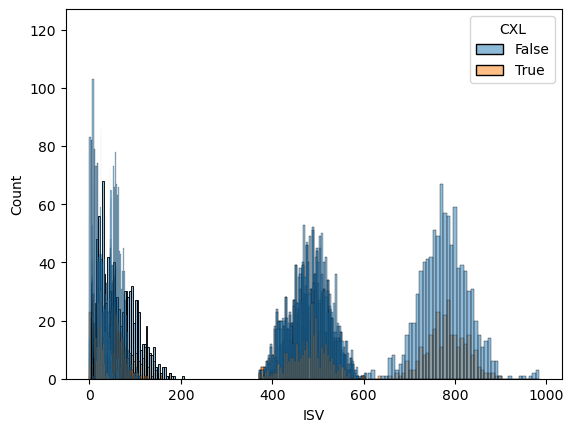

In [11]:
for col in subset_columns:
    fig_p = sns.histplot(df_features,x=col,bins=50, hue='CXL')
    fig_p.figure.savefig('Results/Paper_figs/Single_Tests/'+col.replace(':','') + '.png')

### Train

In [88]:
df_eyes.y.value_counts()

0    475
1    202
Name: y, dtype: int64

0it [00:00, ?it/s]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
1it [00:07,  7.70s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2it [00:14,  6.99s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
3it [00:19,  6.31s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
4it [00:25,  5.92s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
5it [00:30,  5.79s/it]No artists with labels found to put in legend.  Note that artists whose label start wit

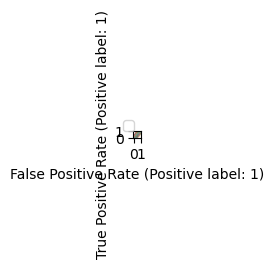

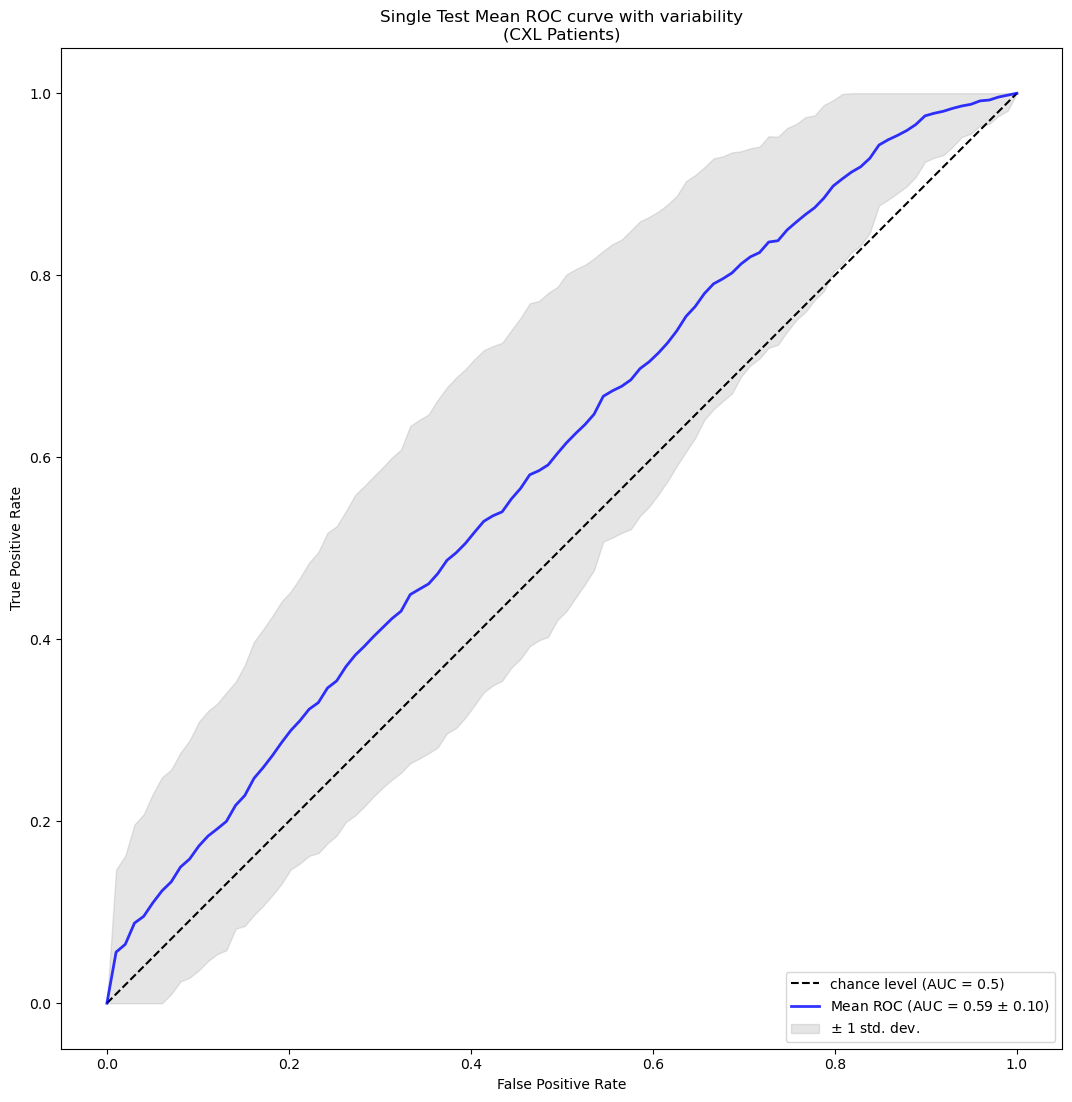

In [94]:
cv = RepeatedStratifiedKFold(n_splits=20, n_repeats=5)    
model_tracker = ModelStatsTracker()
fig1, ax1 = plt.subplots(figsize=(.1, .1))
fig, ax = plt.subplots(figsize=(13, 13))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
folds = []

selected_features = subset_columns # numeric_features


for fold, (train_idx, test_idx) in tqdm(enumerate(cv.split(df_eyes['ideye'], df_eyes['y']))):
    folds.append((train_idx, test_idx))
    X_train = df_features[df_features.ideye.isin(df_eyes['ideye'].iloc[train_idx])][selected_features].values
    y_train = df_features[df_features.ideye.isin(df_eyes['ideye'].iloc[train_idx])]['y'].values

    X_test = df_features[df_features.ideye.isin(df_eyes['ideye'].iloc[test_idx])][selected_features].values
    y_test = df_features[df_features.ideye.isin(df_eyes['ideye'].iloc[test_idx])]['y'].values

    X_train, y_train = SVMSMOTE().fit_sample(X_train, y_train)


    model = xgb.XGBClassifier(booster='dart', 
                        max_depth=15,
                        n_estimators=100,
                        objective='binary:logistic',
                        min_child_weight=5,
                        subsample=0.8,
                        gamma=0.5,
                        colsample_bytree=0.6,
                        use_label_encoder=False,
                        eval_metric='logloss')
    model.fit(X_train, y_train)  
    model_tracker.log(model, X_test, y_test)
    y_pred, y_pred_proba = model.predict(X_test), model.predict_proba(X_test)[:,0]
    
    # print(f'---Fold {fold} -----')
    # print(f'Accuracy: {model.score(X_test,y_test)}')
    # print(f'f-score: {f1_score(y_test, y_pred)}')
    # print(f'roc-auc: {roc_auc_score(y_test,y_pred_proba)}')


    viz = RocCurveDisplay.from_estimator(
    model,
    X_test, y_test,
    name=f"ROC fold {fold}",
    alpha=0.3,
    lw=1,
    ax=ax1,
    label='_'
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)


ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Single Test Mean ROC curve with variability\n(CXL Patients)",
)
ax.axis("square")
ax.legend(loc="lower right")
plt.show()

Mean f1 = 0.31
Mean aps = 0.26
Mean percision = 0.29
Mean recall = 0.33
Mean roc_auc = 0.6


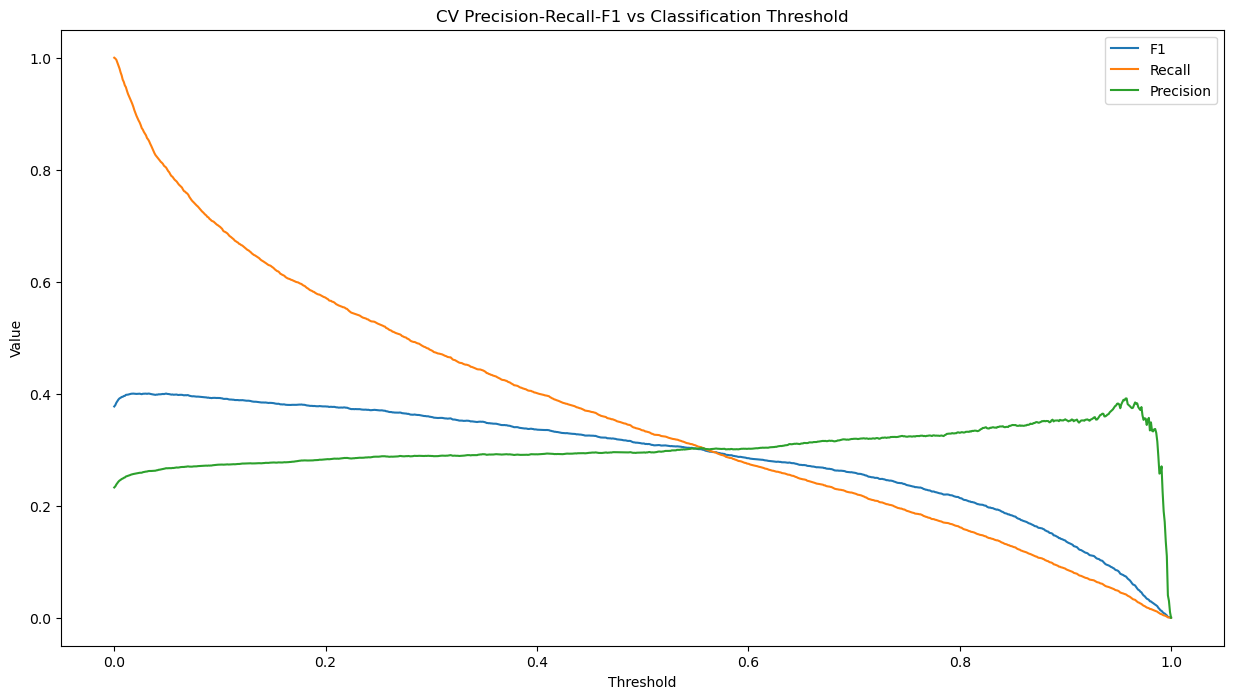

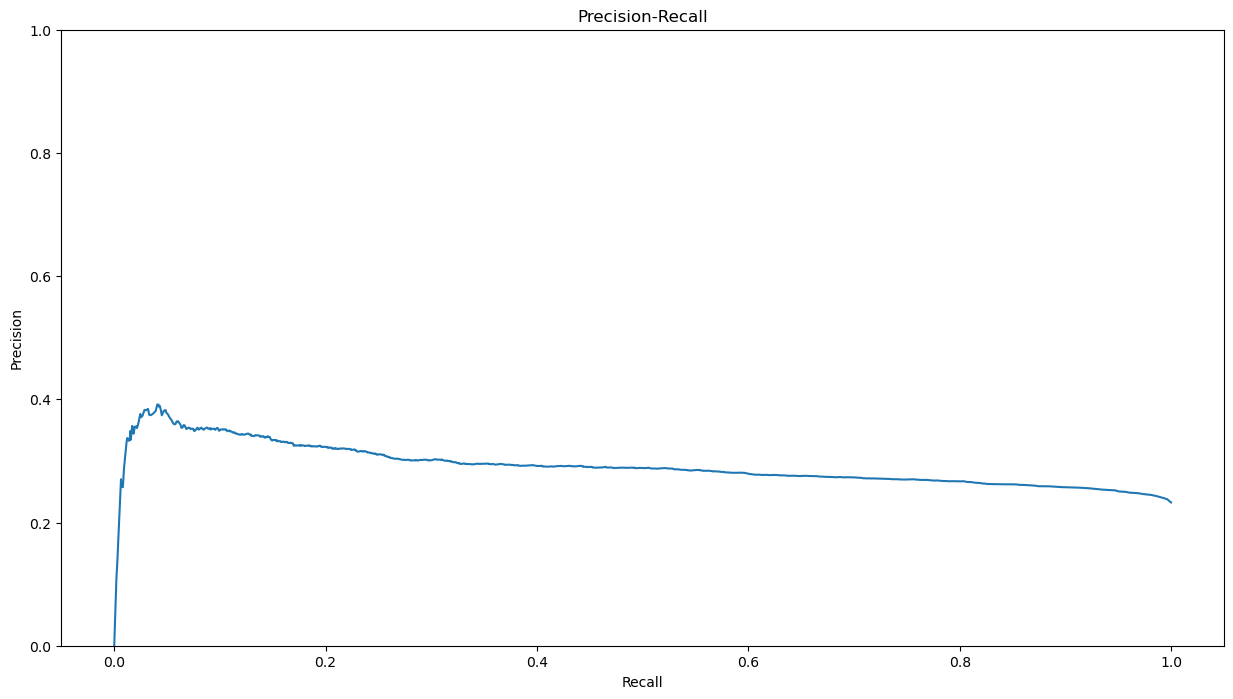

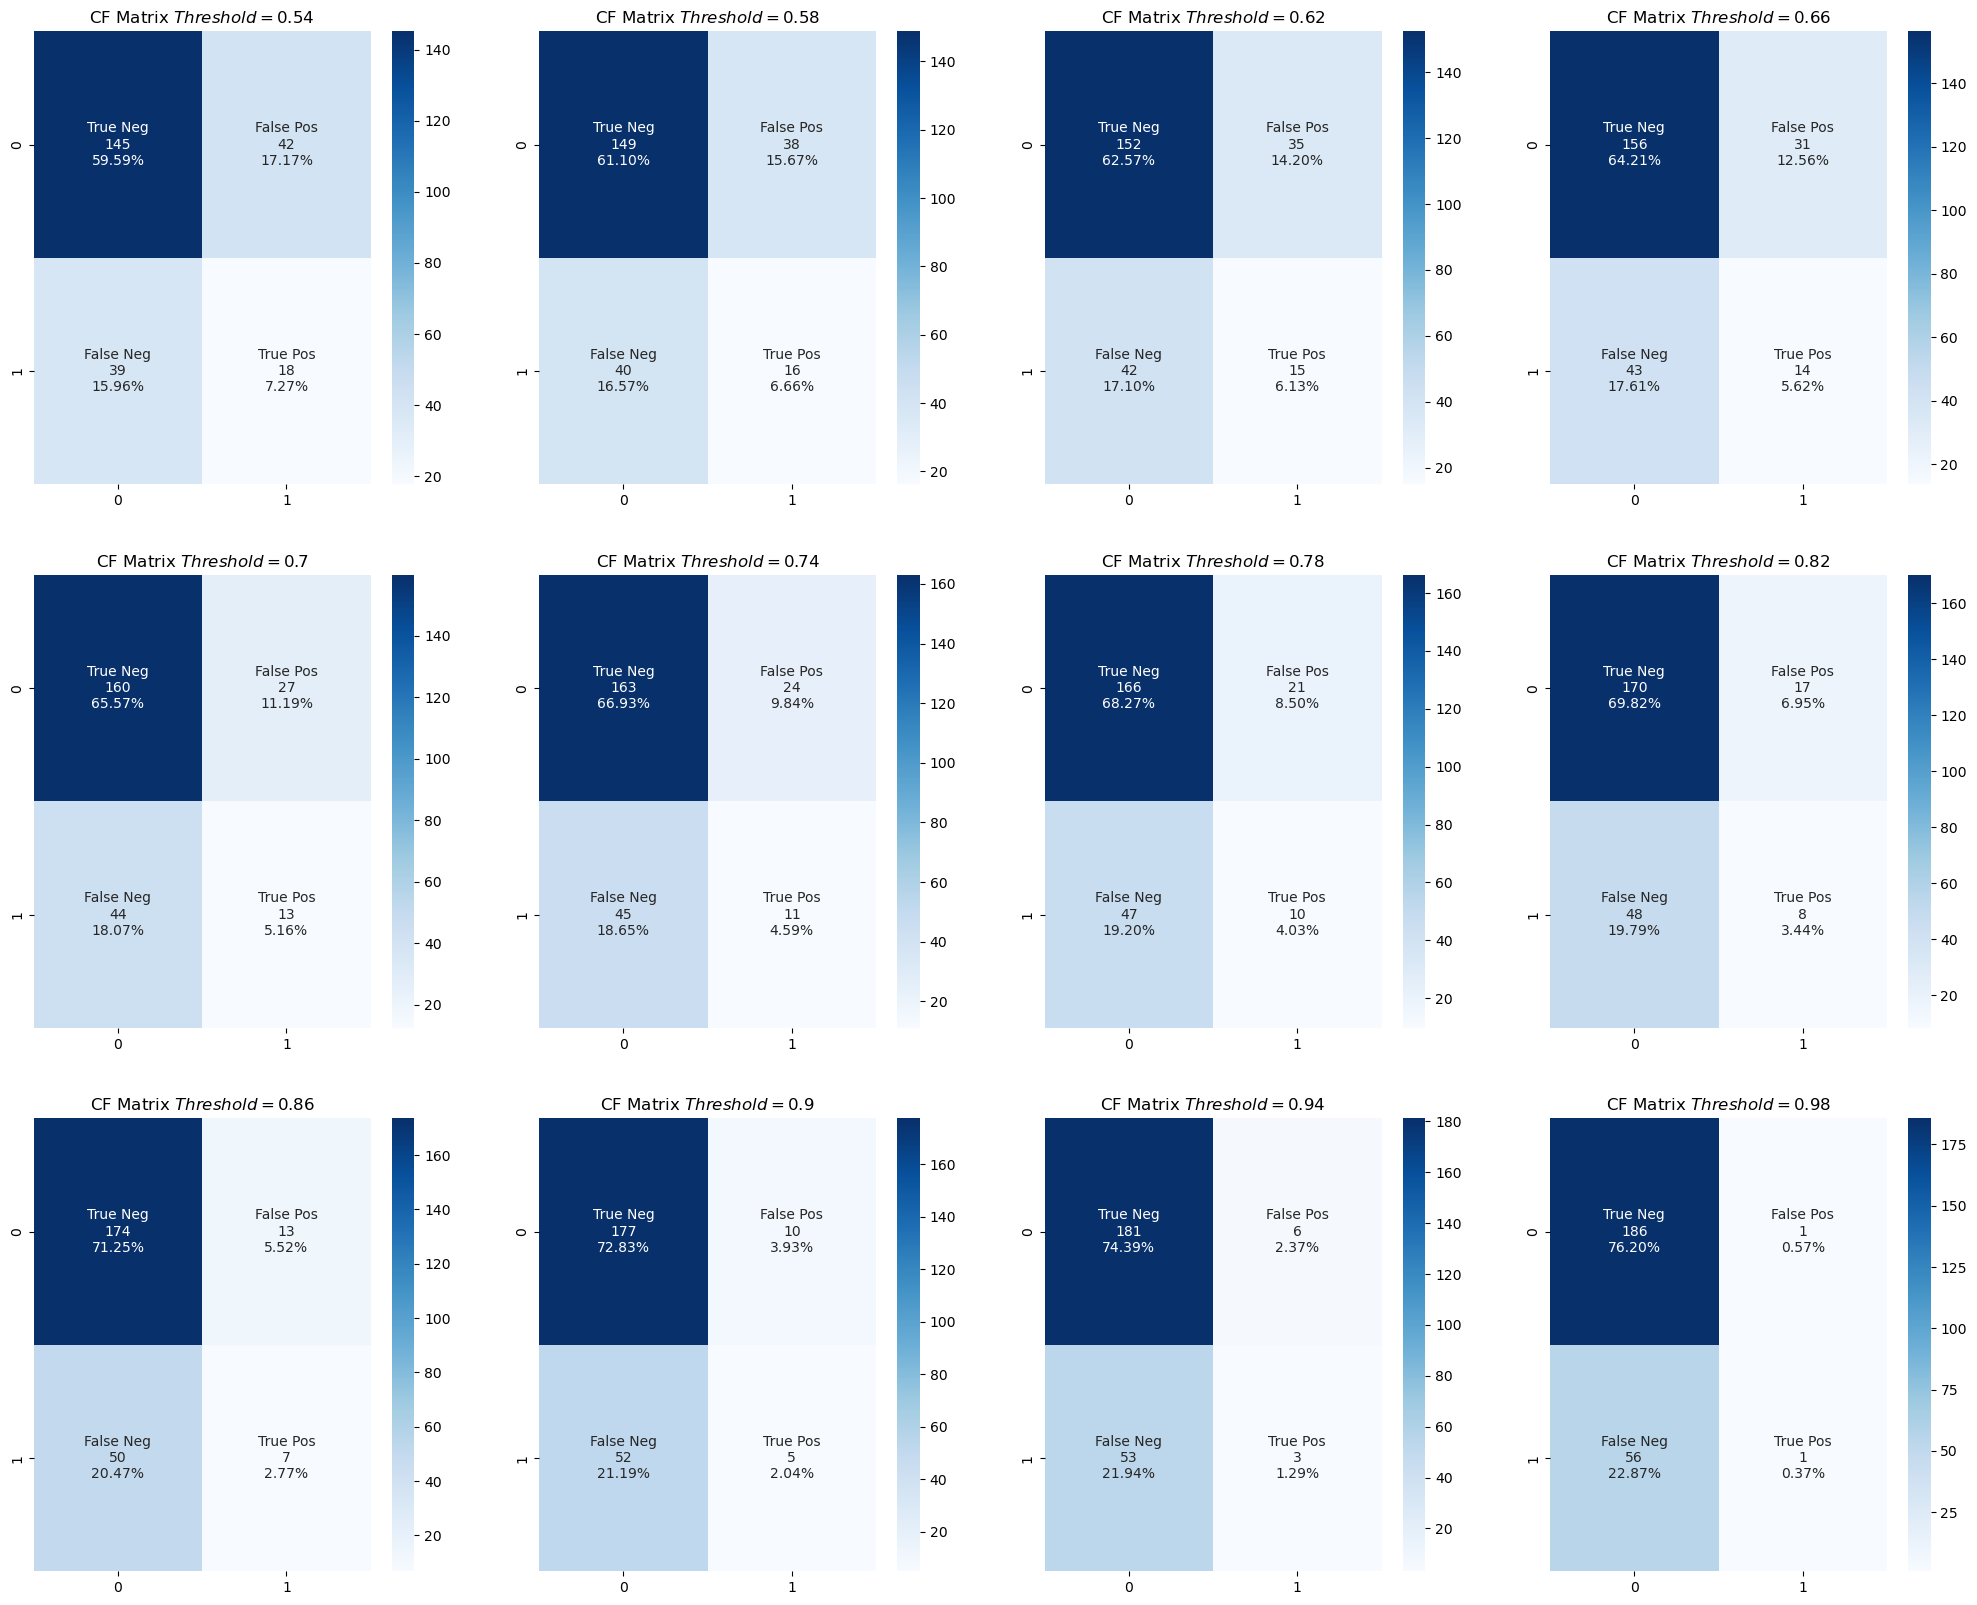

In [90]:
model_tracker.print_mean_values()
model_tracker.plot_metrics()
model_tracker.plot_cf_matrix()

### Hyperparameter Tuning

In [ ]:
folds = 3
param_comb = 5

   
param_grid = {
        'xgb__min_child_weight': [1, 5, 10],
        'xgb__gamma': [0.5, 1, 1.5, 2, 5],
        'xgb__subsample': [0.6, 0.8, 1.0],
        'xgb__colsample_bytree': [0.6, 0.8, 1.0],
        'xgb__max_depth': [3, 4, 5,7,9,11,15,20,23],
        'xgb__n_estimators':[50,100,150,200,400],
        'xgb__scale_pos_weight':[10,20,50,100,200,300,500,700]'
}
smt = SMOTESVN(random_state=42)
model = xgb.XGBClassifier(booster='dart', 
                        objective='binary:logistic',
                        learning_rate=0.01,
                        use_label_encoder=False,
                        eval_metric='logloss')
pipeline = Pipeline([('smt', smt), ('xgb', model)])

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)
X,y = df_train[numeric_features].values, df_train.y.values

random_search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=param_comb, scoring='f1', n_jobs=4, cv=skf.split(X,y), verbose=3, random_state=1001 )

# Here we go
random_search.fit(X, y)

In [ ]:
random_search.best_params_

In [ ]:
rows, cols, idx = int(np.ceil(len(numeric_features)/4)), 4, 0
_, axs = plt.subplots(rows, cols, figsize=(25,50))
for i in range(rows):
    for j in range(cols):
        if idx==len(numeric_features):
            break
        sns.histplot(X_train,x=numeric_features[idx], hue=y_train, ax=axs[i,j])
        idx+=1


In [ ]:
# Sample Weight
counter = Counter(df_train.y)
scale_pos_weight = counter[0] / counter[1]

In [ ]:
#We split over the IDs so there will be no leakage of the training patients to the test ones

cv_base_model_tracker = ModelStatsTracker()

n_repeat = 5
ids_no_dup = df_train['id'].unique()

for irepeat in range(n_repeat):
    kf = KFold(n_splits = 5, shuffle = True, random_state = int(np.power(10,int(10*np.random.rand()))*np.random.rand()))
    for itrain, itest in kf.split(df_train):
        #tdf_train, tdf_test = df[df.id.isin(ids_no_dup[itrain])], df[df.id.isin(ids_no_dup[itest])]
        tdf_train, tdf_test = df_train.iloc[itrain], df_train.iloc[itest]
        X_train, X_test, y_train, y_test = tdf_train[numeric_features], tdf_test[numeric_features], tdf_train.y, tdf_test.y
        

        # Sample Weight
        counter = Counter(y_train)
        scale_pos_weight = counter[0] / counter[1]

        # Model Choice
        model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,use_label_encoder=False,eval_metric='logloss')
        model = xgb.XGBClassifier(booster='dart', 
                                  max_depth=5,
                                  objective='binary:logistic',
                                  #scale_pos_weight=scale_pos_weight,
                                  use_label_encoder=False,
                                  eval_metric='logloss')
        #model = EasyEnsembleClassifier(random_state=42)

        # Should we oversample?
        oversample = RandomOverSampler()
        X_train, y_train = oversample.fit_resample(X_train, y_train)


        #Fit data
        model.fit(X_train, y_train)
        
        cv_base_model_tracker.log(model, X_test, y_test)
        
        

In [ ]:
for k,v in cv_base_model_tracker.metrics.items():
    print(f'{k} -- {np.mean(v)}')

In [ ]:
thresholds = np.linspace(0,1,100)
fig, ax = plt.subplots(figsize=(15,8))
ax.plot(thresholds, np.mean(cv_base_model_tracker.metric_curves[1]['precision'],axis=0), label = 'Precision')
ax.plot(thresholds, np.mean(cv_base_model_tracker.metric_curves[1]['recall'],axis=0), label = 'Recall')
ax.plot(thresholds, np.mean(cv_base_model_tracker.metric_curves[1]['f1'],axis=0), label = 'F1')

# #add axis labels to plot
ax.set_title('CV Precision-Recall-F1 vs Classification Threshold')
ax.set_ylabel('Value')
ax.set_xlabel('Threshold')
plt.legend()

## Multiple Tests Models

In [25]:
numeric_features =['age', 'Rf F (mm):', 'Rs F (mm):', 'Rh F (mm):', 'Rv F (mm):',
       'K1 F (D):', 'K2 F (D):', 'Rm F (mm):', 'Km F (D):',
       'Astig F (D):', 'R Per F (mm)', 'R Min (mm)', 'Num. Ecc. F:',
       'Asph. Q F:', 'Rf B (mm):', 'Rs B (mm):', 'Rh B (mm):', 'Rv B (mm):',
       'K1 B (D):', 'K2 B (D):', 'Rm B (mm):', 'Km B (mm):',
       'Astig B (D):', 'R Per B (mm):', 'R Min B (mm):', 'Num. Ecc. B:',
       'Asph. Q B:', 'Pachy Apex:', 'Pachy Pupil:', 'Pachy Min:', 'Pachy Min Pos X:',
       'Pachy Min Pos Y:', 'C.Vol D 3mm:', 'C.Vol D 5mm:', 'C.Vol D 7mm:',
       'C.Vol D 10mm:', 'ISV:', 'IVA:', 'KI:', 'CKI:', 'IHA:', 'IHD:',
       'RSagMin:', 'D0mm Pachy', 'D2mm Pachy', 'D4mm Pachy',
       'D6mm Pachy', 'D8mm Pachy', 'D10mm Pachy', 'D2mm Prog',
       'D4mm Prog', 'D6mm Prog', 'D8mm Prog', 'D10mm Prog',
       'KMax Sagittal Front (D)']

# Final Data Selection
print('Dropna', len(df))
df_filter = df.copy().dropna(subset=numeric_features)
print(len(df_filter))


#Scan Status
print('Scan Status', len(df_filter))
df_filter = df_filter[df_filter['Status']=='OK']
print(len(df_filter))


#Pachy Min < 370
print('Pachy Min 370', len(df_filter))
df_filter = df_filter[df_filter['Pachy Min:']>370]
print(len(df_filter))


#D10mm Pachy & Prog

for c in ['D10mm Prog','D10mm Pachy']:
    print(c, len(df_filter))
    df_filter = df_filter[df_filter[c]>0]
    print(len(df_filter))
# Abs values
df_filter['Pupil Pos X:']= df_filter['Pupil Pos X:'].abs()
df_filter['Pachy Min Pos X:']= df_filter['Pachy Min Pos X:'].abs()

df_filter['id-eye'] = df_filter.apply(lambda row: f'{row["id"]}-{row["Exam Eye:"]}', axis=1)

df_filter = df_filter.sort_values('Exam Date:')

Dropna 2828
2801
Scan Status 2801
1620
Pachy Min 370 1620
1594
D10mm Prog 1594
1218
D10mm Pachy 1218
1218


In [26]:
df_test_count = df_filter.groupby(['id','Exam Eye:'])['age'].count().reset_index().rename(columns={'age':'ntests'})
df_test_count['id-eye'] = df_test_count.apply(lambda row: f'{row["id"]}-{row["Exam Eye:"]}', axis=1)
df_multitests = df_filter[df_filter['id-eye'].isin(df_test_count[df_test_count.ntests>=2]['id-eye'])]
#pex.histogram(df_test_count, x='id-eye',y='ntests')

In [ ]:
df_test_count

### Pachy Min Further Examination

Finding out outliers

In [ ]:
results = []
convert_to_ts = np.vectorize(lambda x: datetime.datetime.strptime(x,'%Y-%m-%d').timestamp()/86400)
for ideye in df_multitests['id-eye'].unique():
    pachy = df_multitests[df_multitests['id-eye']==ideye]['Pachy Min:'].values
    ts = convert_to_ts(df_multitests[df_multitests['id-eye']==ideye]['Exam Date:'].values)

    if len(pachy)==2:
        results.append([ideye, len(pachy), 0, np.round(np.polyfit(ts,pachy,1)[0],2),pachy])
    else:
        fit = np.polyfit(ts, pachy,1, full=True)
        results.append([ideye,len(pachy), fit[1][0]/len(pachy), np.round(fit[0][0],2),pachy])
df_pachyfit = pd.DataFrame(results, columns=['id-eye','ntests', 'chi2r','coeff', "pachy_min"])

In [29]:
#df_pachyfit.sort_values('coeff',ascending=False).head(50)

In [30]:
print(len(df_multitests))
for ideye, pachy in {'30140661-Right':549.0,'03345174-Right':516.0,'31351509-Right':546.0}.items():
    df_multitests = df_multitests.drop(df_multitests[(df_multitests['id-eye']==ideye) & (df_multitests['Pachy Min:']==pachy)].index)
print(len(df_multitests))

822
819


### Feature Engineering: 1st Order Fitting

In [ ]:
results = []
ids_to_remove = []
convert_to_ts = np.vectorize(lambda x: datetime.datetime.strptime(x,'%Y-%m-%d').timestamp()/(86400))
for ideye in df_multitests['id-eye'].unique():
    try:
        ts = convert_to_ts(df_multitests[df_multitests['id-eye']==ideye]['Exam Date:'].values)
        ts = ts - np.min(ts)
        tmp_res = [ideye,df_multitests[df_multitests['id-eye']==ideye]['y'].iloc[0], len(ts), ts]
        for c in numeric_features:
            vals = df_multitests[df_multitests['id-eye']==ideye][c].values

            if c == 'age':
                tmp_res.append(np.mean(vals))
            else:
                tmp_res.append(np.polyfit(ts, vals, 1)[0])
                
        results.append(tmp_res)
    except:
        ids_to_remove.append(ideye)

df_features = pd.DataFrame(results, columns=['id-eye','y','ntests', 'ts'] + numeric_features)
df_features['id'] = df_features['id-eye'].apply(lambda x: x.split('-')[0])

In [ ]:
cols = 4
rows = len(numeric_features)//cols+1
idx = 0
_, axs = plt.subplots(rows, cols, figsize=(25,50))
for i in range(rows):
    for j in range(cols):
        if idx==len(numeric_features):
            break
        sns.histplot(df_features,x=numeric_features[idx], hue='y', ax=axs[i,j])
        idx+=1

In [32]:
print(f'# Scans: {len(df_features)}')
print(f'#Patients: {len(df_features["id"].unique())}')

print(f'# Scans: {len(df_features[df_features.y==0])}')
print(f'#Patients: {len(df_features[df_features.y==0]["id-eye"].unique())}')
print(f'#Patients: {len(df_features[df_features.y==0]["id"].unique())}')

print(f'# Scans: {len(df_features[df_features.y==1])}')
print(f'#Patients: {len(df_features[df_features.y==1]["id-eye"].unique())}')
print(f'#Patients: {len(df_features[df_features.y==1]["id"].unique())}')

# Scans: 276
#Patients: 218
# Scans: 225
#Patients: 225
#Patients: 190
# Scans: 51
#Patients: 51
#Patients: 45


### Feature Selection

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5)    
subset_columns = []

for fold, (train_idx, test_idx) in enumerate(cv.split(df_features[numeric_features], df_features.y)):
    X_train = df_features.iloc[train_idx][numeric_features]
    y_train = df_features.iloc[train_idx]['y'].values


    Feature_Selector = BorutaShap(
                                importance_measure='shap',
                                classification=True)

    Feature_Selector.fit(X=X_train, y=y_train, n_trials=100, sample=False, normalize=True,
                verbose=True)
    subset_columns+= Feature_Selector.tentative + Feature_Selector.accepted
 
subset_columns = list(set(subset_columns))
pickle.dump(subset_columns, open('Feature_selection_multi_test.bin','wb'))

print(subset_columns)
print(len(subset_columns))

In [4]:
pickle.dump(subset_columns, open('Feature_selection_multi_test.bin','wb'))

In [33]:
subset_columns = pickle.load(open('Feature_selection_multi_test.bin','rb'))
subset_columns

['D10mm Prog',
 'Km F (D):',
 'Pachy Min Pos X:',
 'KMax Sagittal Front (D)',
 'D6mm Prog',
 'C.Vol D 5mm:',
 'Astig B (D):',
 'Rs B (mm):',
 'D4mm Pachy',
 'Rs F (mm):',
 'Rm F (mm):',
 'D2mm Pachy',
 'CKI:',
 'age',
 'D2mm Prog',
 'R Min B (mm):',
 'D8mm Pachy',
 'D10mm Pachy',
 'Pachy Min:',
 'K2 F (D):',
 'Rm B (mm):',
 'D0mm Pachy',
 'Astig F (D):',
 'K1 F (D):',
 'R Per F (mm)',
 'ISV:',
 'K2 B (D):',
 'Rf F (mm):',
 'D4mm Prog',
 'Rv F (mm):',
 'R Per B (mm):',
 'Pachy Pupil:']

### Standartize Feature Names

In [34]:
tmp_subset_columns = []
mapper = {}
for col in subset_columns:
    if col == 'age':
        new_col = 'Mean Age'
    else:
        new_col = col.replace(':','') + ' Rate'

    mapper[col] = new_col
    tmp_subset_columns.append(new_col)
df_features.rename(columns=mapper, inplace=True) 
subset_columns = tmp_subset_columns

### Final Features Distributions

In [35]:
df_features['CXL'] = df_features['y'].astype(bool)

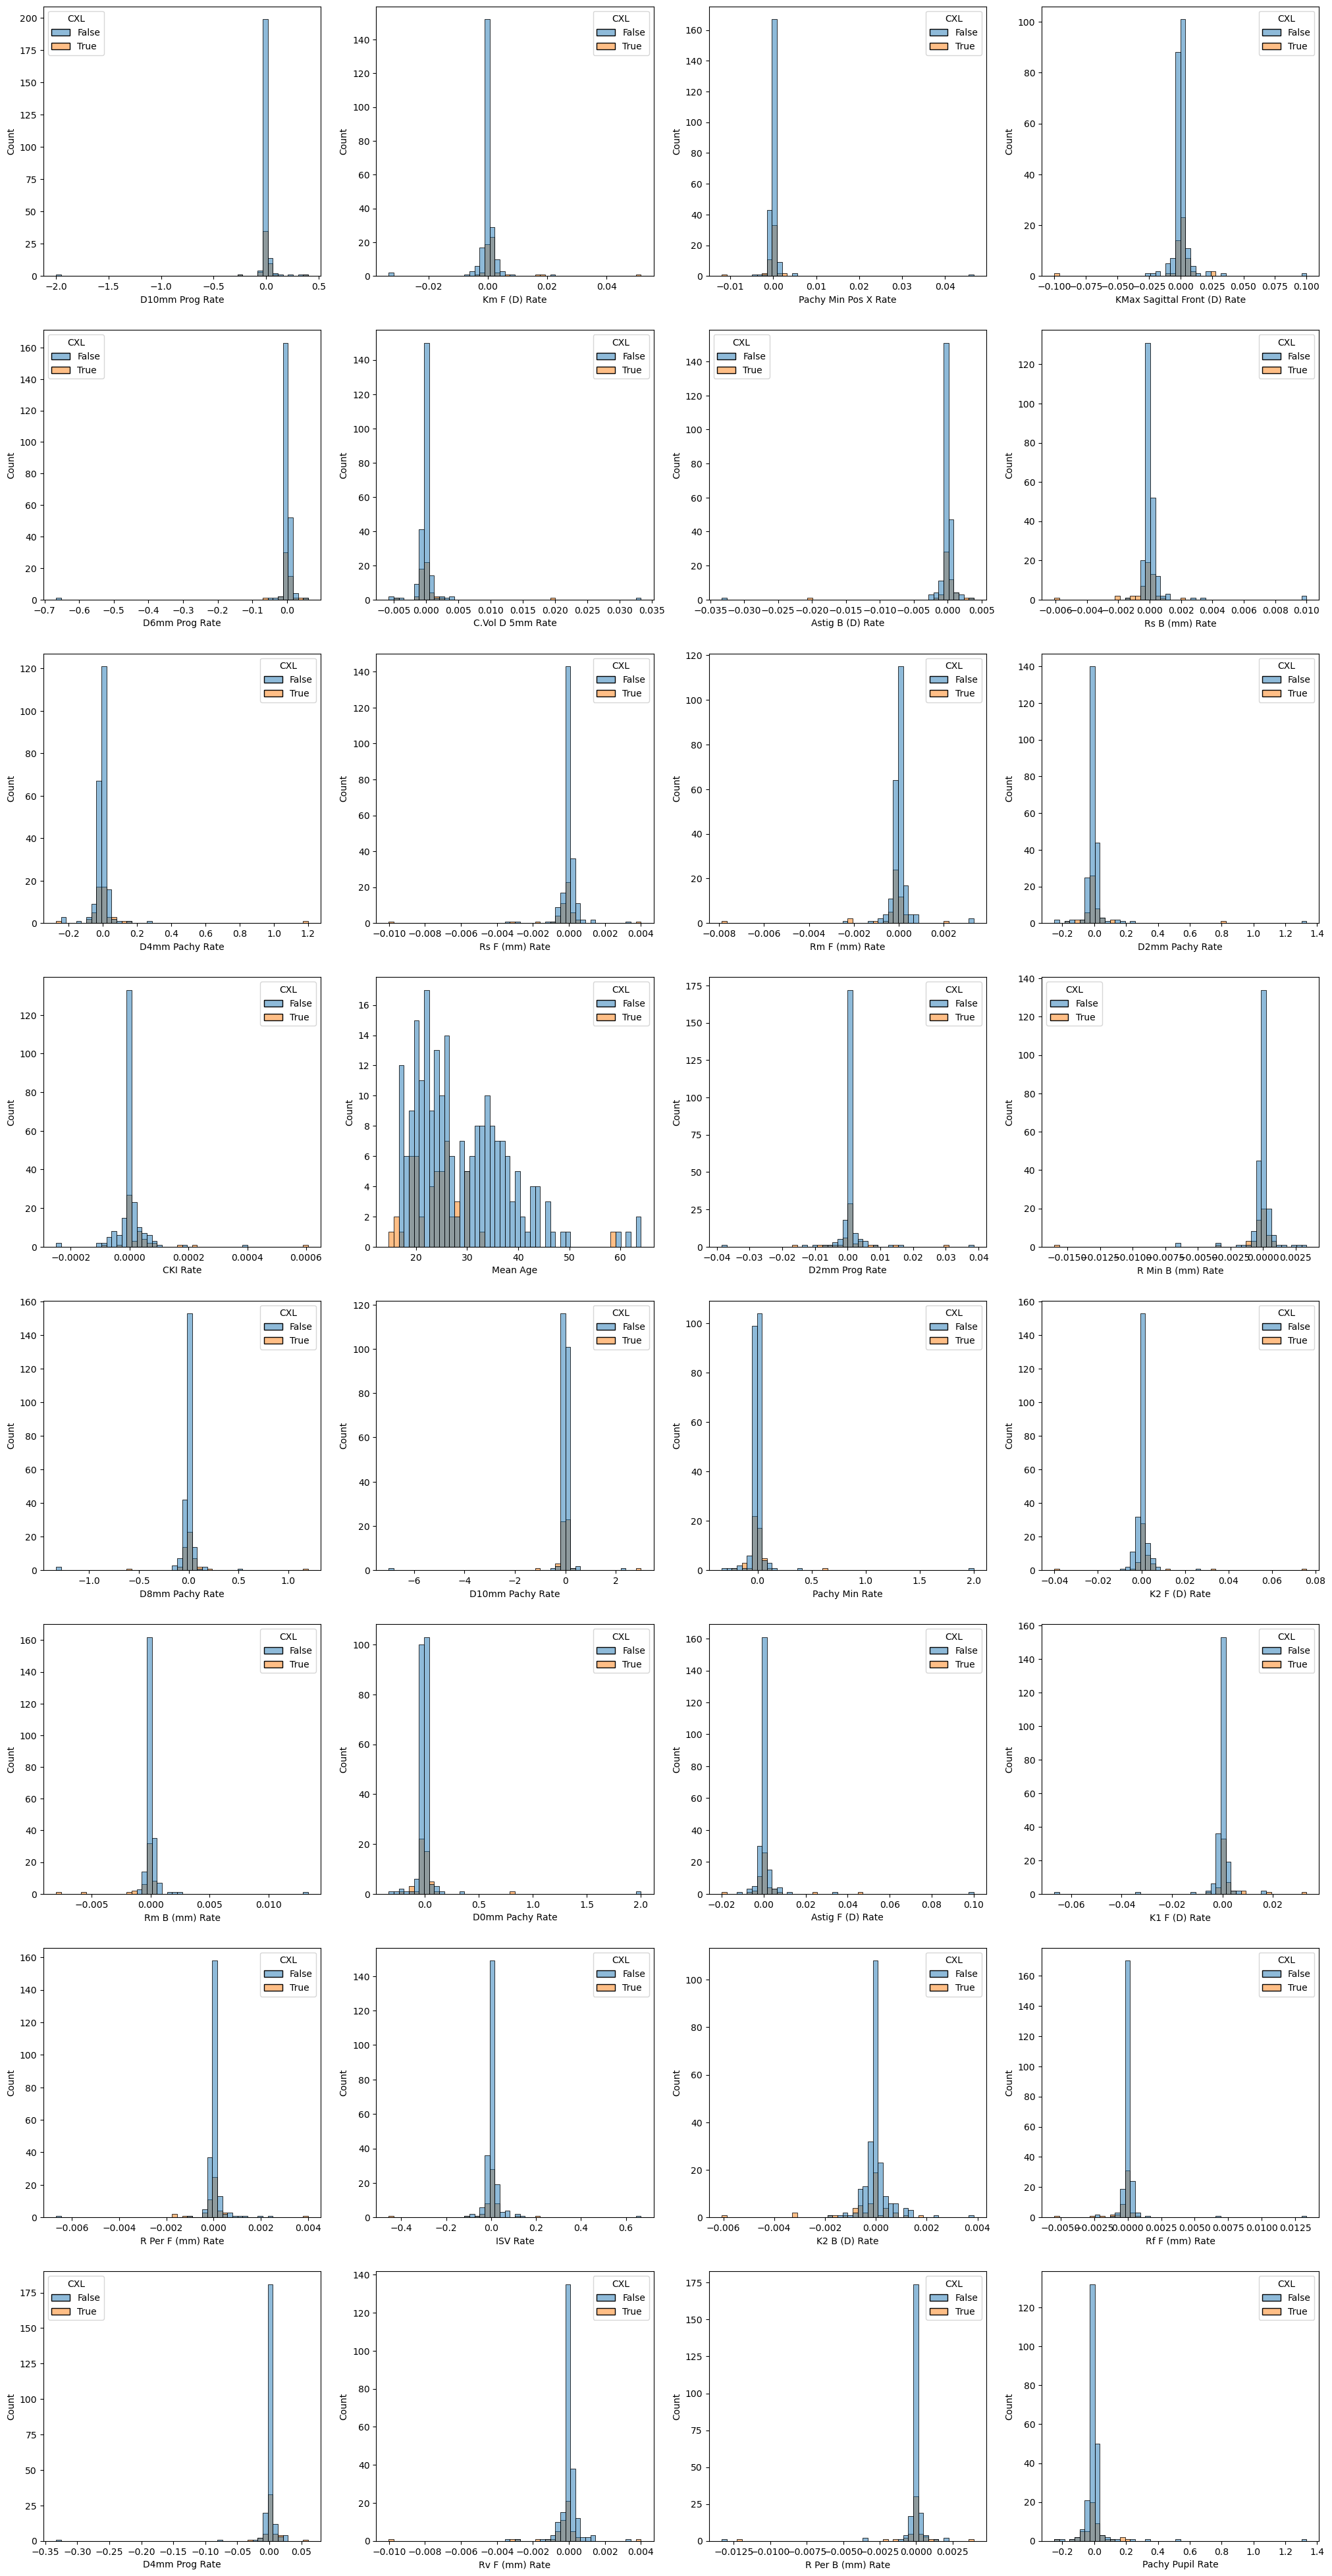

In [60]:
rows, cols, idx = len(subset_columns)//4, 4, 0
_, axs = plt.subplots(rows, cols, figsize=(25,50))
for i in range(rows):
    for j in range(cols):
        if idx==len(subset_columns):
            break
        sns.histplot(df_features,x=subset_columns[idx],bins=50, hue='CXL', ax=axs[i,j])
        idx+=1

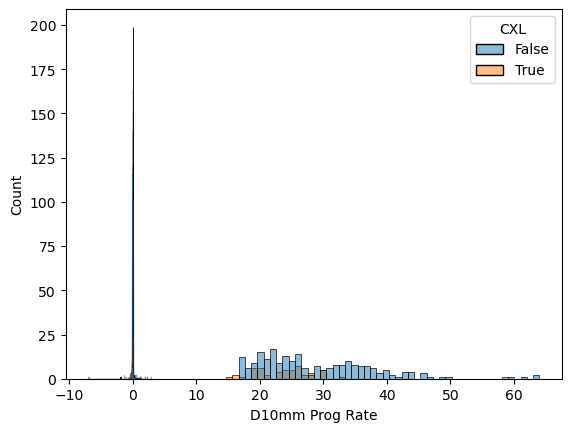

In [62]:
for col in subset_columns:
    fig_p = sns.histplot(df_features,x=col,bins=50, hue='CXL')
    fig_p.figure.savefig('Results/Paper_figs/Multiple_Tests/'+col.replace(':','') + '.png')

### Correlations

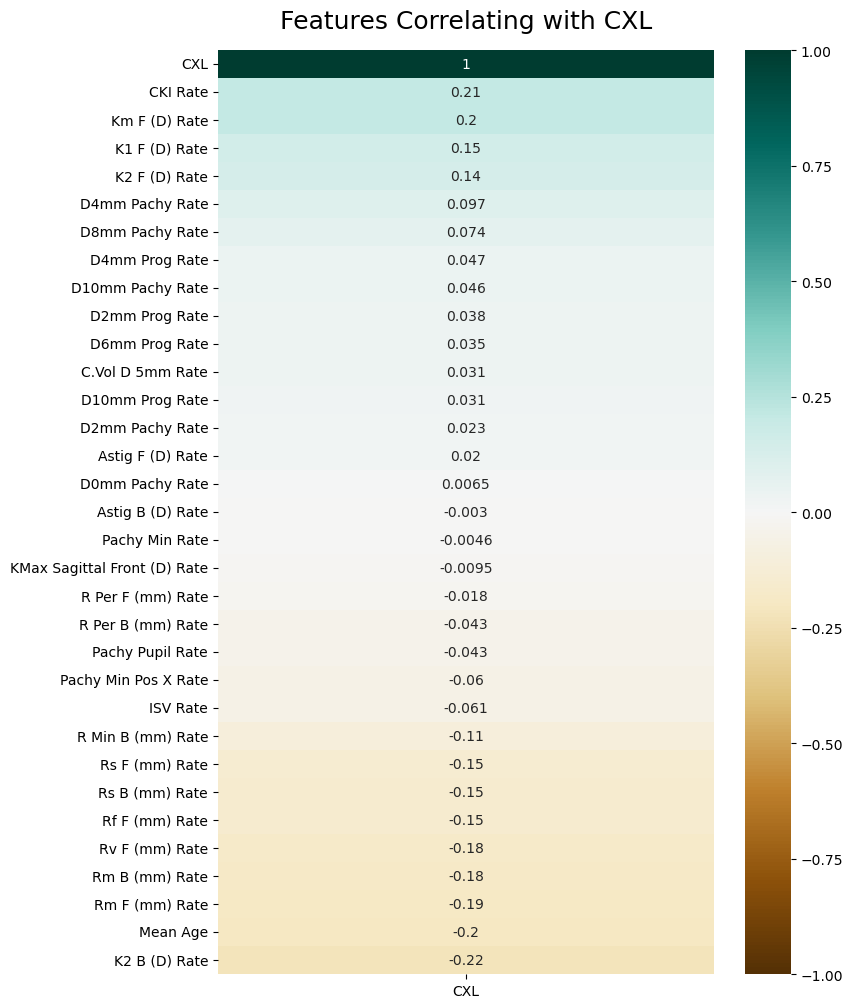

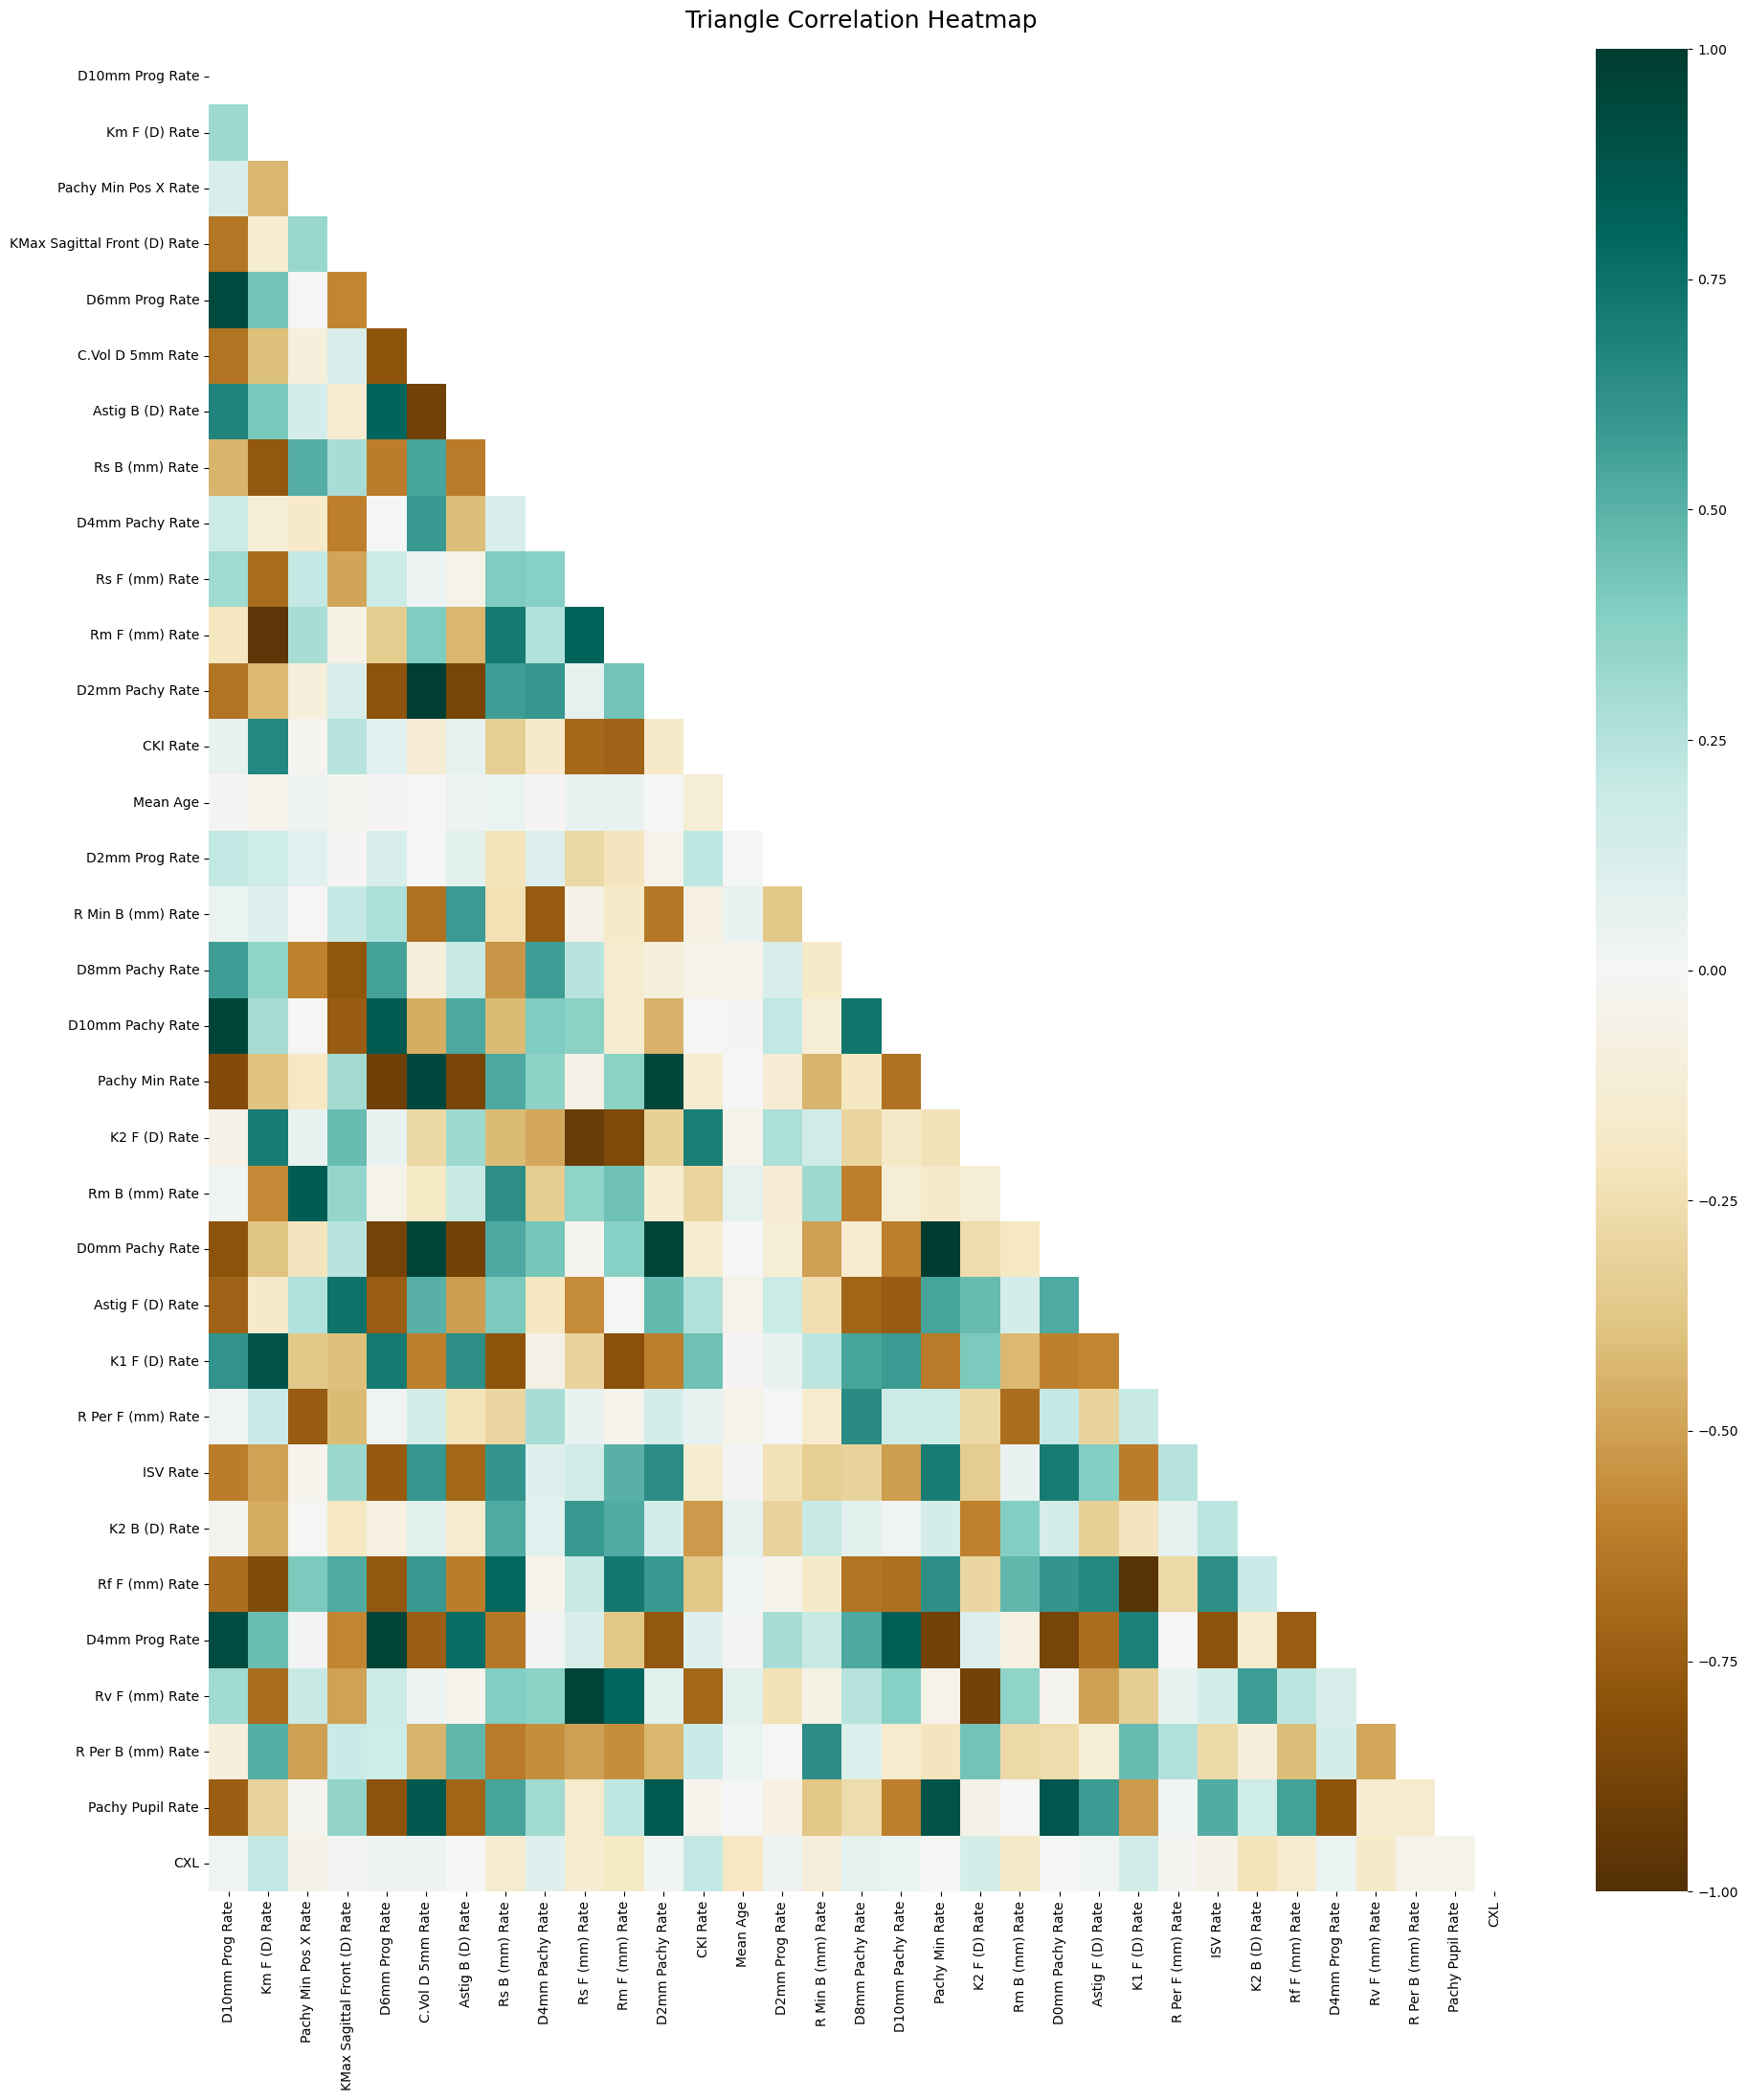

In [65]:
plt.figure(figsize=(8, 12))
heatmap = sns.heatmap(df_features[subset_columns + ['CXL']].corr()[['CXL']].sort_values(by='CXL', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Features Correlating with CXL', fontdict={'fontsize':18}, pad=16);

plt.figure(figsize=(22, 25))
dfcorr = df_features[subset_columns + ['CXL']].corr()
mask = np.triu(np.ones_like(dfcorr, dtype=bool))
heatmap = sns.heatmap(dfcorr, mask=mask, vmin=-1, vmax=1, annot=False, cmap='BrBG')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

### Hyperparameter Tuning

#### Baysien Optimization

In [39]:
selected_features = subset_columns # numeric_features

   
param_grid = {
        'xgb__min_child_weight': [1, 5, 10],
        'xgb__gamma': [0.1, 0.5, 1, 1.5, 2, 5],
        'xgb__subsample': [0.6, 0.8, 1.0],
        'xgb__colsample_bytree': [0.6, 0.8, 1.0],
        'xgb__max_depth': [3, 4, 5,7,9,11,15,20,23,30],
        'xgb__n_estimators':[35, 50,100,150,200,400],
        'xgb__scale_pos_weight':[5,10,15,20,50,100,200,300,500,700],
        'xgb__learning_rate':[0.001,0.01,0.1]
}
smt = SVMSMOTE()
model = xgb.XGBClassifier(booster='gbtree', 
                        objective='binary:logistic',
                        use_label_encoder=False,
                        eval_metric='logloss')
pipeline = Pipeline([('smt', smt), ('xgb', model)])

skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 1001)
X,y = df_features[selected_features].values, df_features.y.values


opt = BayesSearchCV(
    pipeline,
    # (parameter space, # of evaluations)
    [(param_grid, 100)],
    cv=skf.split(X,y)
)

# Here we go
opt.fit(X, y)
print("Best Params:")
for k,v in opt.best_params_.items():
    print(f'{k}:  {v}')

Best Params:
xgb__colsample_bytree:  1.0
xgb__gamma:  0.5
xgb__learning_rate:  0.1
xgb__max_depth:  4
xgb__min_child_weight:  1
xgb__n_estimators:  150
xgb__scale_pos_weight:  5
xgb__subsample:  0.6


#### Random Search

In [ ]:
folds = 10
param_comb = 50
selected_features = list(set(subset_columns)) # numeric_features

   
param_grid = {
        'xgb__min_child_weight': [1, 5, 10],
        'xgb__gamma': [0.5, 1, 1.5, 2, 5],
        'xgb__subsample': [0.6, 0.8, 1.0],
        'xgb__colsample_bytree': [0.6, 0.8, 1.0],
        'xgb__max_depth': [3, 4, 5,7,9,11,15,20,23],
        'xgb__n_estimators':[50,100,150,200,400],
        'xgb__scale_pos_weight':[10,20,50,100,200,300,500,700],
}
smt = SVMSMOTE()
model = xgb.XGBClassifier(booster='dart', 
                        objective='binary:logistic',
                        learning_rate=0.01,
                        use_label_encoder=False,
                        eval_metric='logloss')
pipeline = Pipeline([('smt', smt), ('xgb', model)])

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)
X,y = df_features[selected_features].values, df_features.y.values

random_search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=param_comb, scoring='f1', n_jobs=4, cv=skf.split(X,y), verbose=3, random_state=1001 )

# Here we go
random_search.fit(X, y)

In [122]:
random_search.best_params_

{'xgb__subsample': 0.6,
 'xgb__scale_pos_weight': 10,
 'xgb__n_estimators': 50,
 'xgb__min_child_weight': 1,
 'xgb__max_depth': 23,
 'xgb__gamma': 1,
 'xgb__colsample_bytree': 0.6}

### Final Data Statistics

In [66]:
print(df_features.y.value_counts())
print(len(df_features))

0    225
1     51
Name: y, dtype: int64
276


In [43]:
print(df_multitests.y.value_counts())
print(len(df_multitests))

0    685
1    134
Name: y, dtype: int64
819


In [44]:
pex.histogram(df_features,x='ntests').update_layout(
     xaxis_title="# Scans Per Patient"
)

### Train

0it [00:00, ?it/s]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
1it [00:03,  3.06s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
2it [00:05,  2.92s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
3it [00:08,  2.89s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
4it [00:11,  2.76s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
5it [00:13,  2.71s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscore ar

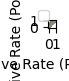

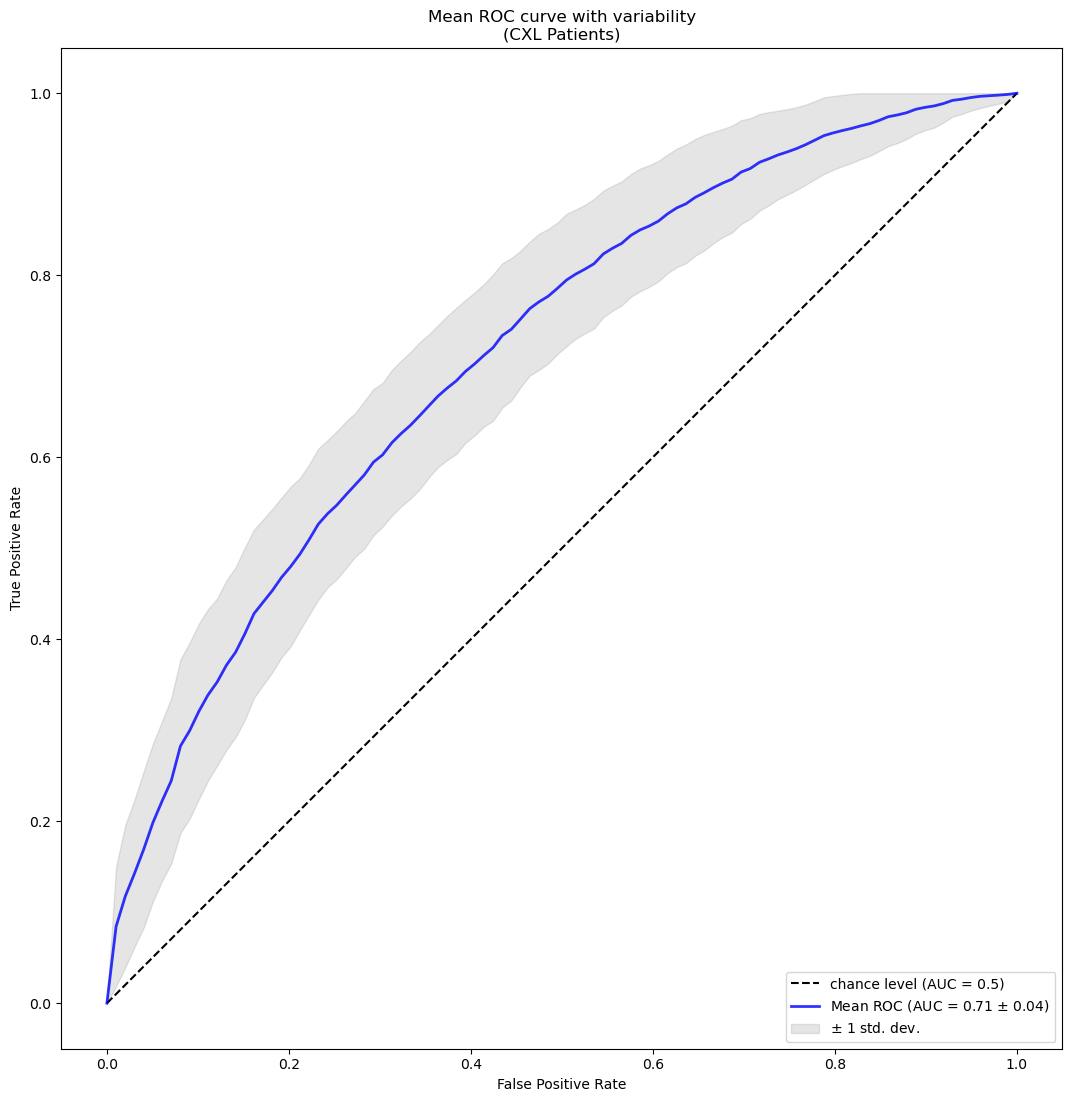

In [75]:
cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=150)    
model_tracker = ModelStatsTracker()
fig1, ax1 = plt.subplots(figsize=(.1, .1))
fig, ax = plt.subplots(figsize=(13, 13))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
folds = []

selected_features = subset_columns 

list_shap_values, list_test_sets = [], []
booster = 'dart' #gbtree/dart

for fold, (train_idx, test_idx) in tqdm(enumerate(cv.split(df_features[selected_features], df_features.y.values))):
    folds.append((train_idx, test_idx))
    X_train = df_features.iloc[train_idx][selected_features]
    y_train = df_features.iloc[train_idx]['y'].values

    X_test = df_features.iloc[test_idx][selected_features]
    y_test = df_features.iloc[test_idx]['y'].values

    X_train, y_train = SVMSMOTE().fit_resample(X_train, y_train)

    model = xgb.XGBClassifier(booster=booster, 
                            max_depth=4,
                            n_estimators=150,
                            objective='binary:logistic',
                            min_child_weight=1,
                            subsample=0.6,
                            learning_rate=0.1,
                            gamma=0.5,
                            colsample_bytree=1.0,
                            scale_pos_weight = 5,
                            eval_metric='logloss')

    model.fit(X_train, y_train)  
    model_tracker.log(model, X_test, y_test)
    y_pred, y_pred_proba = model.predict(X_test), model.predict_proba(X_test)[:,1]
    # print(f'---Fold {fold} -----')
    # print(f'Accuracy: {model.score(X_test,y_test)}')
    # print(f'f-score: {f1_score(y_test, y_pred)}')
    # print(f'roc-auc: {roc_auc_score(y_test,y_pred_proba)}')

    #explaining model
    if booster == 'gbtree':
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
        #for each iteration we save the test_set index and the shap_values
        list_shap_values.append(shap_values)
        list_test_sets.append(test_idx)

    viz = RocCurveDisplay.from_estimator(
    model,
    X_test, y_test,
    name=f"ROC fold {fold}",
    alpha=0.3,
    lw=1,
    ax=ax1,
    label = '_' #remove all the semi-rocs from the legend
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)


ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(CXL Patients)",
)
ax.axis("square")
ax.legend(loc="lower right")
plt.show()

Text(0.5, 1.0, 'SHAP Values')

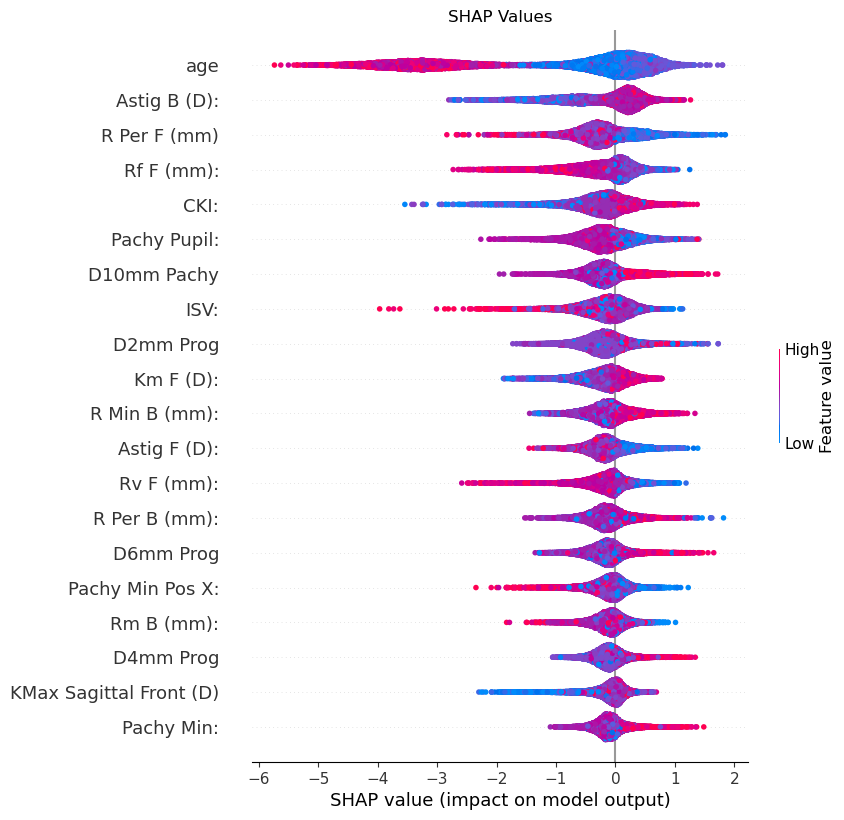

In [47]:
min_test_size = 1e10
for arr in list_test_sets:
    if arr.shape[0] < min_test_size:
        min_test_size = arr.shape[0]

#combining results from all iterations
test_set = list_test_sets[0][:min_test_size]
shap_values = np.array(list_shap_values[0][:min_test_size])
for i in range(1,len(list_test_sets)):
    test_set = np.concatenate((test_set,list_test_sets[i][:min_test_size]),axis=0)
    shap_values = np.concatenate((shap_values,np.array(list_shap_values[i][:min_test_size])),axis=0)
#bringing back variable names    
X_test = pd.DataFrame(df_features.iloc[test_set][selected_features],columns=selected_features)

#creating explanation plot for the whole experiment
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Values')

In [84]:
pickle.dump(model_tracker,open('Results/Paper_figs/final_trained_multiple_tests_model_tracker.bin','wb'))

In [13]:
model_tracker = pickle.load(open('Results/Paper_figs/final_trained_multiple_tests_model_tracker.bin','rb'))

In [76]:
model_tracker.print_mean_values()

Mean f1 = 0.39
Mean aps = 0.27
Mean percision = 0.38
Mean recall = 0.42
Mean roc_auc = 0.71


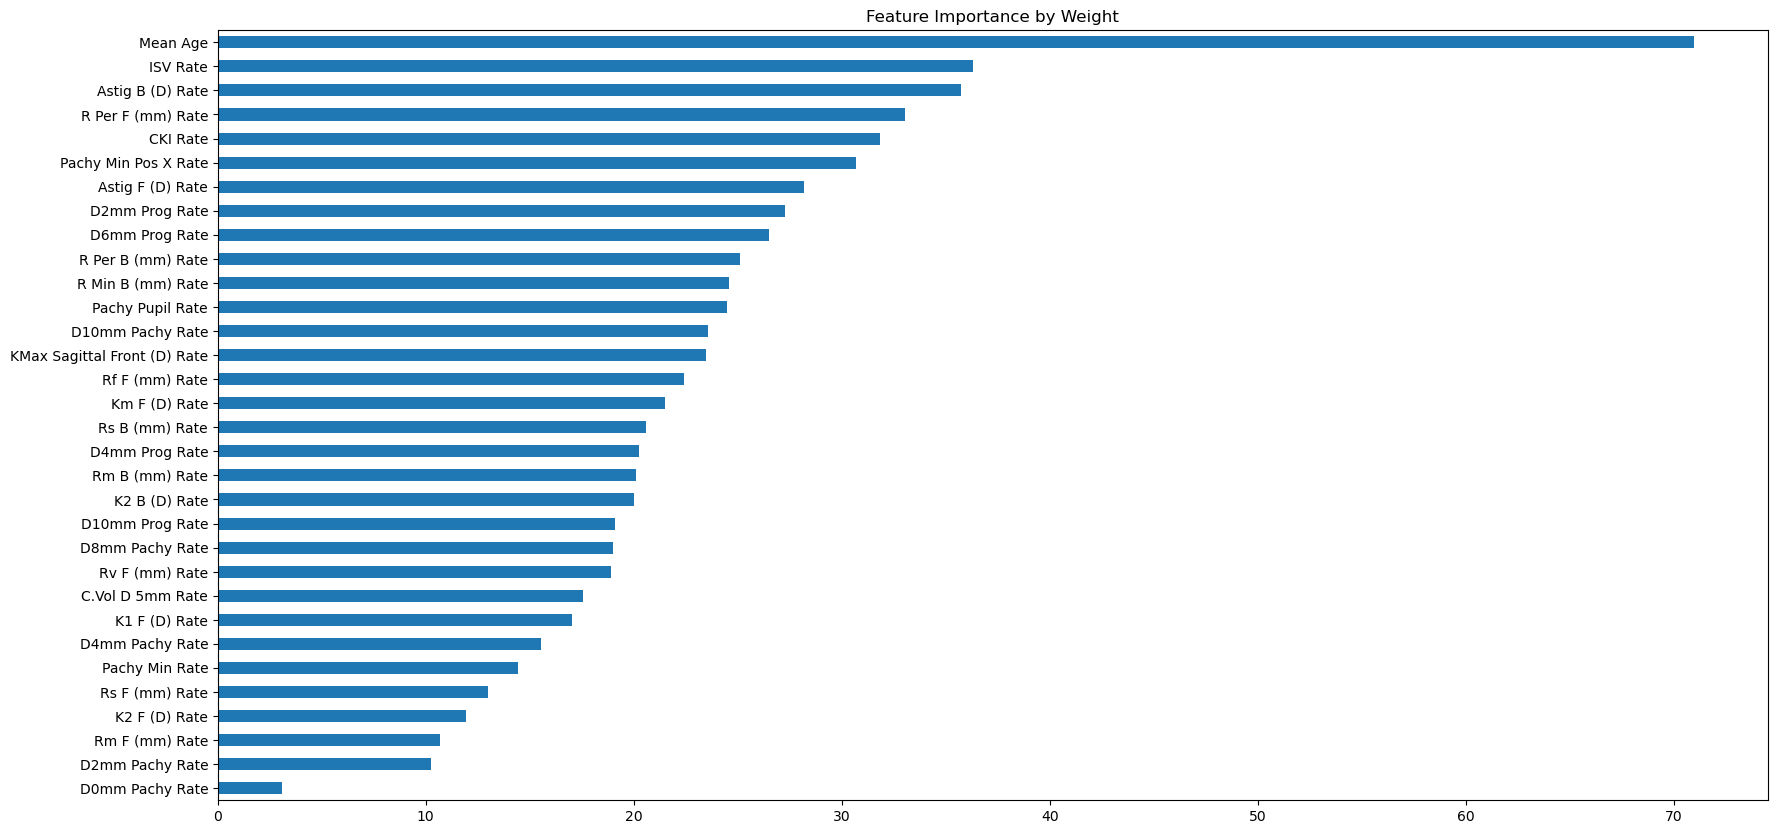

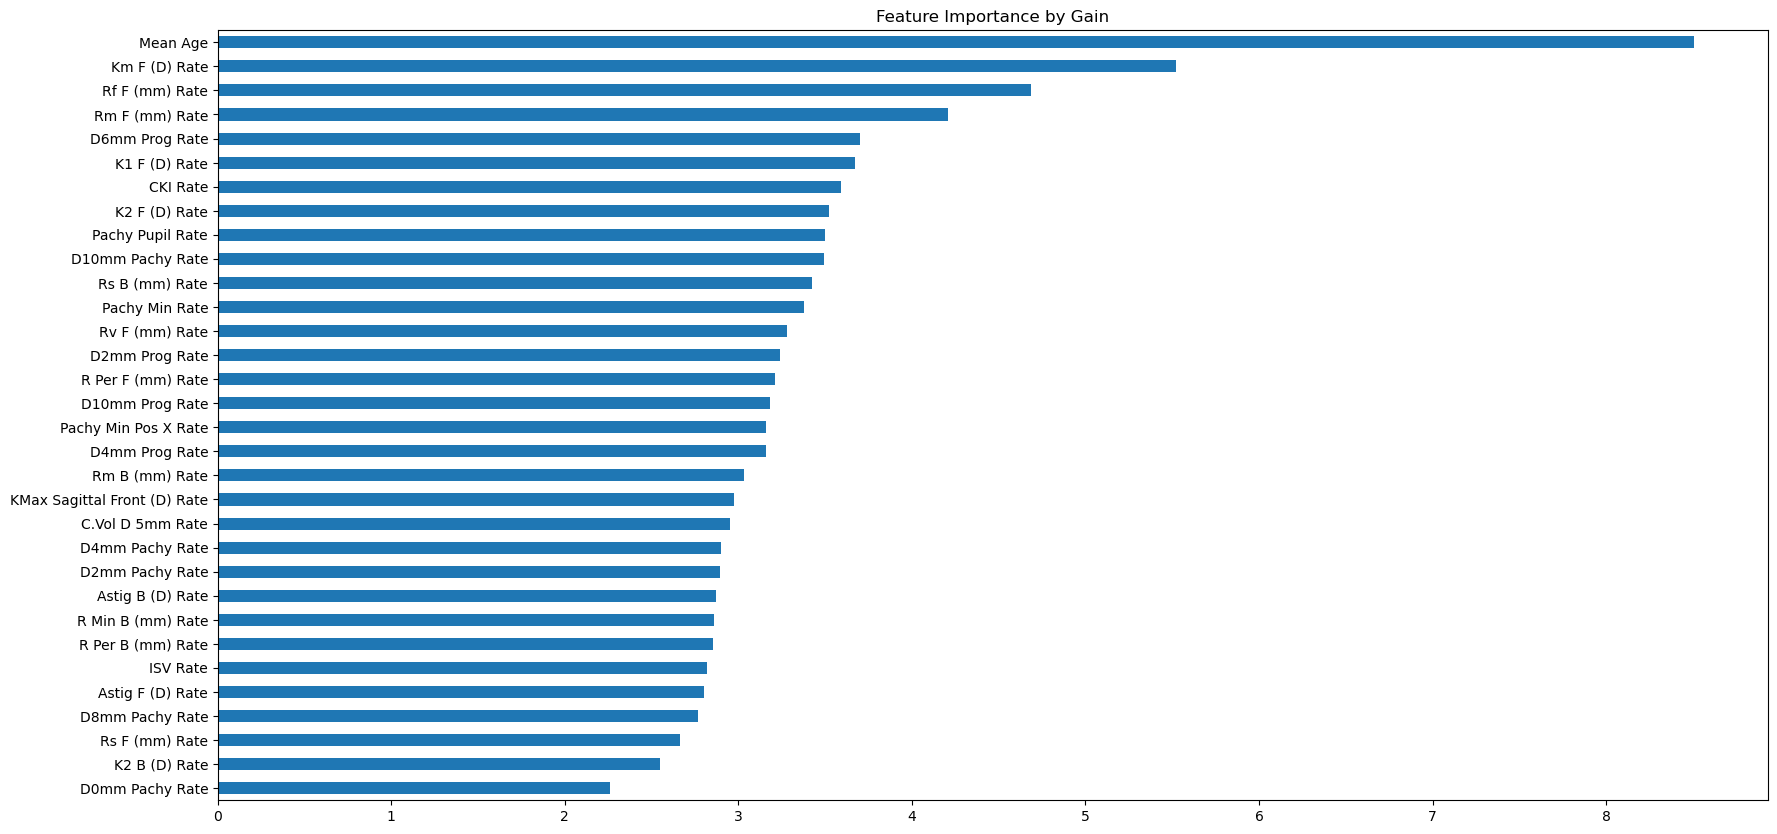

In [86]:
model_tracker.plot_feature_importance()

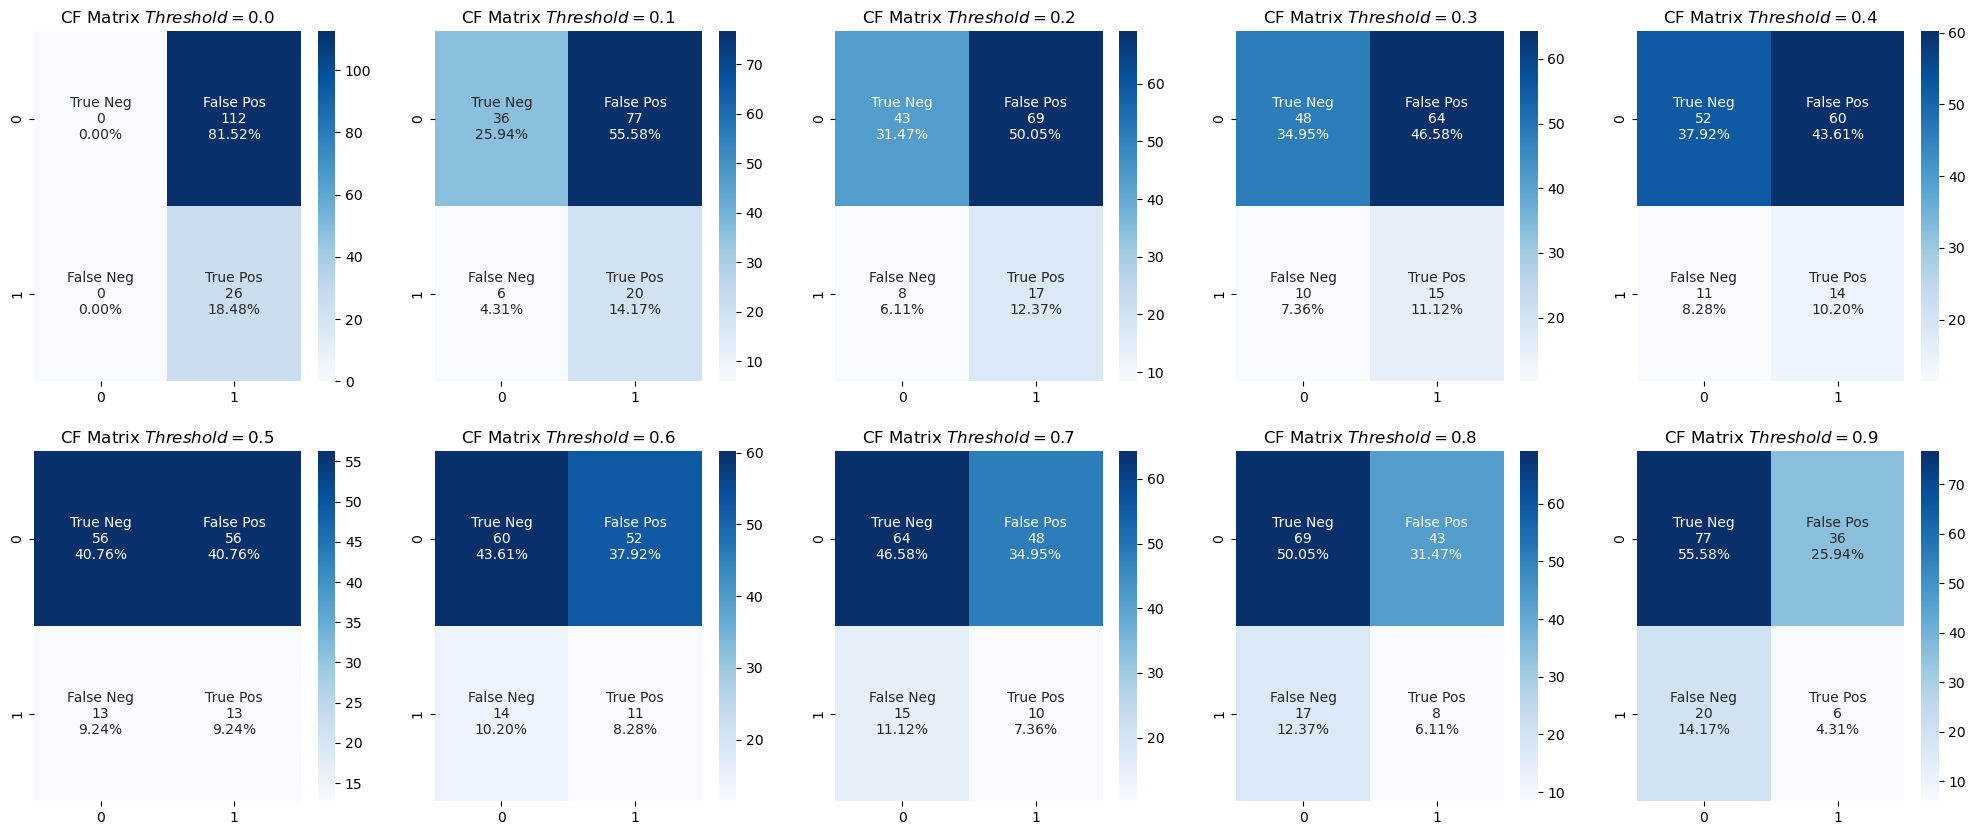

In [72]:
model_tracker.plot_all_cf_matrices()

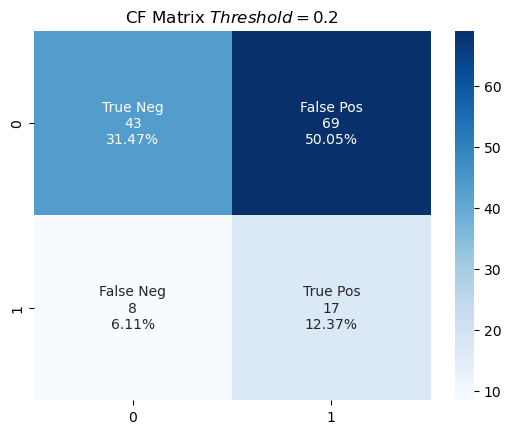

In [73]:
model_tracker.plot_cf_matrix(0.2)
#np.linspace(0,1,21)

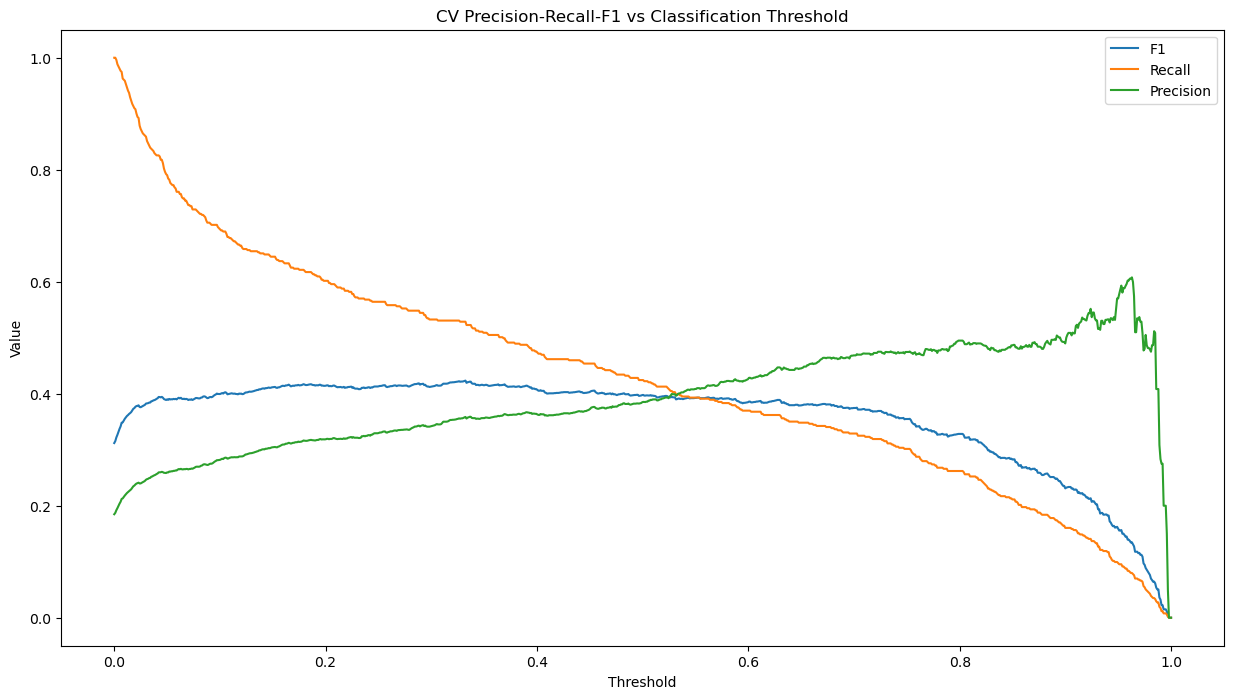

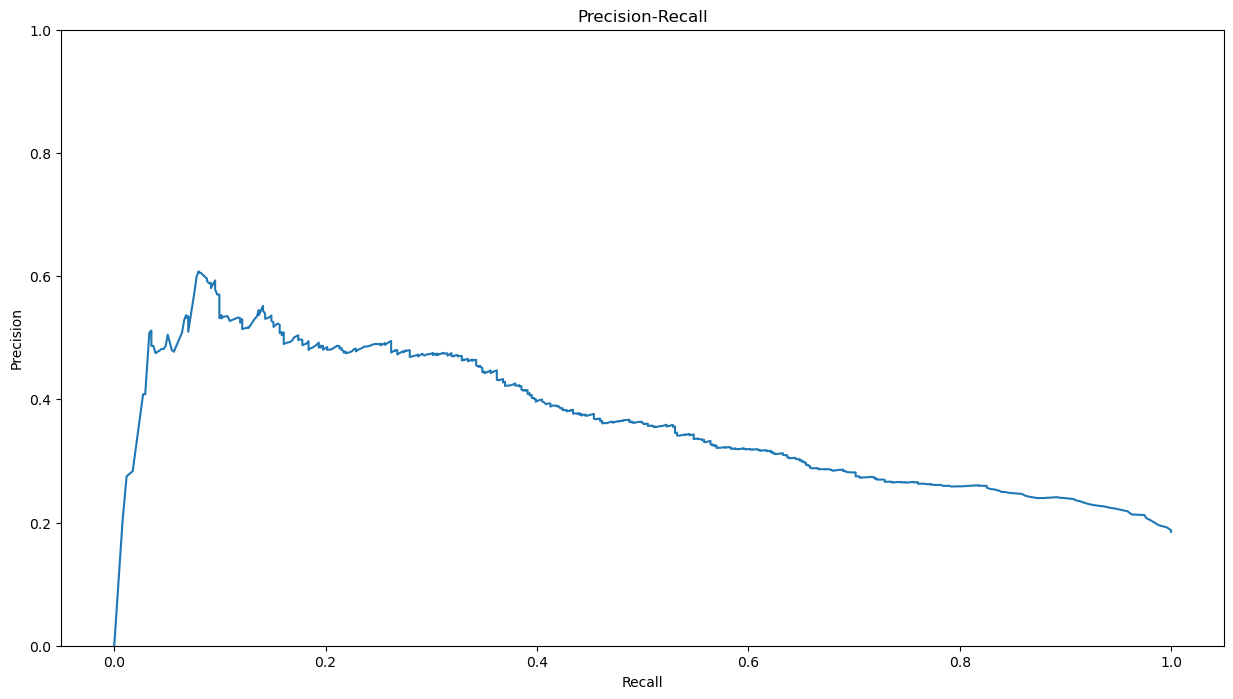

In [74]:
model_tracker.plot_metrics()

## Testing Grounds

### ROCKET

In [ ]:
data = defaultdict(list)
ys = []
convert_to_ts = np.vectorize(lambda x: datetime.datetime.strptime(x,'%Y-%m-%d').timestamp()/86400)
for ideye in df_multitests['id-eye'].unique():
    current_data = [ideye]
    ts = convert_to_ts(df_multitests[df_multitests['id-eye']==ideye]['Exam Date:'].values)
    data['ts'].append(pd.Series(ts[:2]))

    ys.append(df_multitests[df_multitests['id-eye']==ideye]['y'].iloc[0])

    for var in numeric_features:
        var_vals = df_multitests[df_multitests['id-eye']==ideye][var].values[:2]
        data[var].append(pd.Series(var_vals))

In [ ]:
df_features = pd.DataFrame(data)
df_features['y'] = ys
df_features['id-eye'] = df_multitests['id-eye'].unique()
df_features.y.describe()

In [ ]:
df_features

In [ ]:
from sktime.transformations.panel.padder import PaddingTransformer
from sktime.classification.kernel_based import RocketClassifier
from sklearn.linear_model import RidgeClassifierCV



In [ ]:
cv = RepeatedStratifiedKFold(n_splits=200, n_repeats=10)    
model_tracker = ModelStatsTracker()
fig, ax = plt.subplots(figsize=(13, 13))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
folds = []
selected_features = list(set(subset_columns)) # numeric_features


for fold, (train_idx, test_idx) in enumerate(cv.split(df_features[selected_features], df_features.y)):
    folds.append((train_idx, test_idx))
    X_train = df_features.iloc[train_idx][selected_features]
    y_train = df_features.iloc[train_idx]['y'].values

    X_test = df_features.iloc[test_idx][selected_features]
    y_test = df_features.iloc[test_idx]['y'].values


    # X_train = padder.fit_transform(X_train)
    # X_test = padder.fit_transform(X_test)

    rocket = Rocket()
    rocket.fit(X_train)
    X_train = rocket.transform(X_train)
    X_test = rocket.transform(X_test)
    
    X_train, y_train = SVMSMOTE().fit_sample(X_train, y_train)

    model = xgb.XGBClassifier(booster='dart', 
                            max_depth=5,
                            n_estimators=35,
                            objective='binary:logistic',
                            min_child_weight=5,
                            subsample=0.8,
                            gamma=0.5,
                            scale_pos_weight = 20,
                            colsample_bytree=0.6,
                            use_label_encoder=False,
                            eval_metric='logloss')

    model.fit(X_train, y_train)  
    model_tracker.log(model, X_test, y_test)
    y_pred, y_pred_proba = model.predict(X_test), model.predict_proba(X_test)[:,1]
    print(f'---Fold {fold} -----')
    print(f'Accuracy: {model.score(X_test,y_test)}')
    print(f'f-score: {f1_score(y_test, y_pred)}')
    print(f'roc-auc: {roc_auc_score(y_test,y_pred_proba)}')


    viz = RocCurveDisplay.from_estimator(
    model,
    X_test, y_test,
    name=f"ROC fold {fold}",
    alpha=0.3,
    lw=1,
    ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)


ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"Mean ROC curve with variability\n(CXL Patients)",
)
ax.axis("square")
ax.legend(loc="lower right")
plt.show()

In [ ]:
df_transform = Rocket().fit_transform(PaddingTransformer().fit_transform(df_features[numeric_features]))

In [ ]:
pca = PCA(2).fit_transform(df_transform)
fig_2d = pex.scatter(
    pca, x=0, y=1,
    color=df_features.y.astype(str), labels={'color': 'CXL'},
    
)

fig_2d.update_traces(marker_size=3)

fig_2d.show()


In [ ]:
fig_2d = pex.scatter(
    pca, x=0, y=1,
    color=df_features.y.astype(str), labels={'color': 'CXL'},
    
)

fig_2d.update_traces(marker_size=3)

fig_2d.show()


In [ ]:
X,y = df_train, df_train.y.values

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    
    X_train, y_train = X[numeric_features].values[train_idx], y[train_idx]   
    X_test, y_test = X[numeric_features].values[test_idx], y[test_idx]
    train_ids = X.id.iloc[train_idx]
    test_ids = X.id.iloc[test_idx]


In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
for train_idx, test_idx in cv.split(eyes.ideye, eyes.y):
    mitzi = 0

In [ ]:
df_train[df_train.ideye.isin(eyes.ideye.iloc[train_idx])]

Data Prep

In [ ]:
def clean_dataset(df):
    assert isinstance(df, pd.DataFrame), "df needs to be a pd.DataFrame"
    df.dropna(inplace=True)
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    return df[indices_to_keep].astype(np.float64)

In [ ]:
df = pd.read_csv('data/221204_v2/KC_filtered_by_date_labeled.csv')

training_features =['Rf F (mm):', 'Rs F (mm):', 'Rh F (mm):', 'Rv F (mm):',
       'K1 F (D):', 'K2 F (D):', 'Rm F (mm):', 'Km F (D):', 'Axis F (flat):',
       'Astig F (D):', 'R Per F (mm)', 'R Min (mm)', 'Num. Ecc. F:',
       'Asph. Q F:', 'Rf B (mm):', 'Rs B (mm):', 'Rh B (mm):', 'Rv B (mm):',
       'K1 B (D):', 'K2 B (D):', 'Rm B (mm):', 'Km B (mm):', 'Axis B (flat):',
       'Astig B (D):', 'R Per B (mm):', 'R Min B (mm):', 'Num. Ecc. B:',
       'Asph. Q B:', 'Pachy Apex:', 'Pachy Pupil:',
       'Pupil Pos X:', 'Pupil Pos Y:', 'Pachy Min:', 'Pachy Min Pos X:',
       'Pachy Min Pos Y:', 'C.Vol D 3mm:', 'C.Vol D 5mm:', 'C.Vol D 7mm:',
       'C.Vol D 10mm:', 'ISV:', 'IVA:', 'KI:', 'CKI:', 'IHA:', 'IHD:',
       'RSagMin:', 'D0mm Pachy', 'D2mm Pachy', 'D4mm Pachy',
       'D6mm Pachy', 'D8mm Pachy', 'D10mm Pachy', 'D0mm Prog', 'D2mm Prog',
       'D4mm Prog', 'D6mm Prog', 'D8mm Prog', 'D10mm Prog',
       'KMax Sagittal Front (D)']



#df = df.reindex(np.random.permutation(df.index))   
#df = df.reset_index(drop=True) 
df = df[df.Status=='OK'][training_features + ['id','y']]
df = clean_dataset(df)

#### Easy Ensamble

In [ ]:
oversample = RandomOverSampler(sampling_strategy='minority')

In [ ]:
X = df[training_features]
y = df.y

ids_no_dup = np.unique(df.id)
y_ids_no_dup = df.groupby('id').y.first()[ids_no_dup].values
ids_train, ids_test = train_test_split(ids_no_dup, test_size=0.3, shuffle=True, stratify=y_ids_no_dup, random_state=42)

train, test = [], []
for s in ids_train:
    train.append(df.loc[df.id==s])
for s in ids_test:
    test.append(df.loc[df.id==s])

train, test = pd.concat(train, ignore_index=True), pd.concat(test, ignore_index=True)
X_train, X_test, y_train, y_test = train[training_features], test[training_features], train.y, test.y

oversample = RandomOverSampler(sampling_strategy='minority')
X_over, y_over = oversample.fit_resample(X_train, y_train)


In [ ]:
eec = EasyEnsembleClassifier(random_state=42)
eec.fit(X_over, y_over)
y_pred_prob = eec.predict_proba(X_test)[:,1]

In [ ]:
prf_plot(y_pred_prob, y_test)

In [ ]:
cf_matrix = confusion_matrix(y_test, (y_pred_prob>0.5).astype(int))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')

### Classic XGB

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_train[training_features], df_train.y, test_size=0.3)

In [ ]:
model = xgb.XGBClassifier(booster='dart', 
                                max_depth=5,
                                objective='binary:logistic',
                                #scale_pos_weight=scale_pos_weight,
                                use_label_encoder=False,
                                eval_metric='logloss')
model.fit(X_train, y_train)

In [ ]:
f1_score(model.predict(X_test),y_test)

In [ ]:
y_pred_prob = model.predict_proba(X_test)[:,1]
cf_matrix = confusion_matrix(y_test, (y_pred_prob>0.5).astype(int))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')